In [1]:
import torch
import pandas as pd
import numpy as np

def format_pytorch_version(version):
  return version.split('+')[0]

TORCH_VERSION = format_pytorch_version(torch.__version__)
CUDA_VERSION = 'cu' + torch.version.cuda.replace('.', '') if torch.cuda.is_available() else 'cpu'

print(f"Installing torch_geometric and its dependencies for PyTorch {TORCH_VERSION} and CUDA {CUDA_VERSION}...")
!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-{TORCH_VERSION}+{CUDA_VERSION}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-{TORCH_VERSION}+{CUDA_VERSION}.html
!pip install -q torch_geometric
print("Installation complete.")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from imblearn.over_sampling import SMOTE

from sklearn.neighbors import kneighbors_graph
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

import matplotlib.pyplot as plt
import seaborn as sns

Installing torch_geometric and its dependencies for PyTorch 2.11.0 and CUDA cpu...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.1/682.1 kB 14.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.8 MB/s eta 0:00:00
Installation complete.


In [2]:
df = pd.read_csv('obesity.csv', sep=';', decimal=',')
df.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21,Female,1.62,64,no,no,2,3,no,no,2,yes,0,1,Sometimes,Public_Transportation,Normal_Weight
1,21,Female,1.52,56,Sometimes,no,3,3,yes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight
2,23,Male,1.80,77,Frequently,no,2,3,no,no,2,yes,2,1,Sometimes,Public_Transportation,Normal_Weight
3,27,Male,1.80,87,Frequently,no,3,3,no,no,2,no,2,0,Sometimes,Walking,Overweight_Level_I
4,22,Male,1.78,90,Sometimes,no,2,1,no,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II


In [3]:
df.tail()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
2106,20,Female,1.71,132,Sometimes,yes,3,3,no,no,1,yes,1,0,Sometimes,Public_Transportation,Obesity_Type_III
2107,21,Female,1.75,134,Sometimes,yes,3,3,no,no,2,yes,1,0,Sometimes,Public_Transportation,Obesity_Type_III
2108,22,Female,1.75,134,Sometimes,yes,3,3,no,no,2,yes,1,0,Sometimes,Public_Transportation,Obesity_Type_III
2109,24,Female,1.74,133,Sometimes,yes,3,3,no,no,2,yes,1,0,Sometimes,Public_Transportation,Obesity_Type_III
2110,23,Female,1.74,133,Sometimes,yes,3,3,no,no,2,yes,1,0,Sometimes,Public_Transportation,Obesity_Type_III


In [4]:
df.rename(columns={
    'Gender': 'gender',
    'Age': 'age',
    'family_history_with_overweight': 'family_history',
    'FAVC': 'high_calorie_food',
    'FCVC': 'vegetable_consumption',
    'NCP': 'meal_per_day',
    'CAEC': 'snacking',
    'SMOKE': 'smoking',
    'CH2O': 'water_intake',
    'SCC': 'calorie_monitoring',
    'FAF': 'physical_activity',
    'TUE': 'screen_time',
    'CALC': 'alcohol',
    'MTRANS': 'transport',
    'NObeyesdad': 'label'
}, inplace=True)
df.sample(5)

,age,gender,Height,Weight,alcohol,high_calorie_food,vegetable_consumption,meal_per_day,calorie_monitoring,smoking,water_intake,family_history,physical_activity,screen_time,snacking,transport,label
2022,25,Female,1.61,104,Sometimes,yes,3,3,no,no,1,yes,0,0,Sometimes,Public_Transportation,Obesity_Type_III
1240,23,Female,1.67,83,no,yes,2,1,no,no,2,yes,0,1,Sometimes,Public_Transportation,Obesity_Type_I
1574,25,Male,1.76,115,Sometimes,yes,2,3,no,no,2,yes,1,1,Sometimes,Public_Transportation,Obesity_Type_II
1143,24,Male,1.70,84,Sometimes,yes,2,3,no,no,2,yes,0,1,Sometimes,Public_Transportation,Overweight_Level_II
1760,31,Male,1.77,120,Sometimes,yes,2,3,no,no,2,yes,0,0,Sometimes,Automobile,Obesity_Type_II


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    2111 non-null   int64  
 1   gender                 2111 non-null   object 
 2   Height                 2111 non-null   float64
 3   Weight                 2111 non-null   int64  
 4   alcohol                2111 non-null   object 
 5   high_calorie_food      2111 non-null   object 
 6   vegetable_consumption  2111 non-null   int64  
 7   meal_per_day           2111 non-null   int64  
 8   calorie_monitoring     2111 non-null   object 
 9   smoking                2111 non-null   object 
 10  water_intake           2111 non-null   int64  
 11  family_history         2111 non-null   object 
 12  physical_activity      2111 non-null   int64  
 13  screen_time            2111 non-null   int64  
 14  snacking               2111 non-null   object 
 15  tran

In [6]:
df.isnull().sum()

,0
age,0
gender,0
Height,0
Weight,0
alcohol,0
high_calorie_food,0
vegetable_consumption,0
meal_per_day,0
calorie_monitoring,0
smoking,0


In [7]:
df.duplicated().sum()

np.int64(281)

In [8]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [9]:
df.shape

(1830, 17)

In [10]:
df.describe()

,age,Height,Weight,vegetable_consumption,meal_per_day,water_intake,physical_activity,screen_time
count,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000
mean,23.971038,1.702831,85.574317,2.178689,2.515301,1.700000,0.766120,0.410383
std,6.560542,0.095253,43.150197,0.581550,0.836259,0.601756,0.852071,0.596510
min,14.000000,1.450000,10.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.000000,1.630000,64.000000,2.000000,2.000000,1.000000,0.000000,0.000000
50%,22.000000,1.700000,81.000000,2.000000,3.000000,2.000000,1.000000,0.000000
75%,26.000000,1.770000,104.000000,3.000000,3.000000,2.000000,1.000000,1.000000
max,61.000000,1.980000,975.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [11]:
# Kolom kategorikal
categorical_cols = df.select_dtypes(include=['object']).columns
print("Kolom Kategorikal:", categorical_cols)

# Kolom numerik
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Kolom Numerik:", numerical_cols)

Kolom Kategorikal: Index(['gender', 'alcohol', 'high_calorie_food', 'calorie_monitoring',
       'smoking', 'family_history', 'snacking', 'transport', 'label'],
      dtype='object')
Kolom Numerik: Index(['age', 'Height', 'Weight', 'vegetable_consumption', 'meal_per_day',
       'water_intake', 'physical_activity', 'screen_time'],
      dtype='object')


In [12]:
df.columns = df.columns.str.strip()
df = df[df['age'] >= 18].reset_index(drop=True)

df = df.drop(columns=['Height', 'Weight'], errors='ignore')
df.shape

(1722, 15)

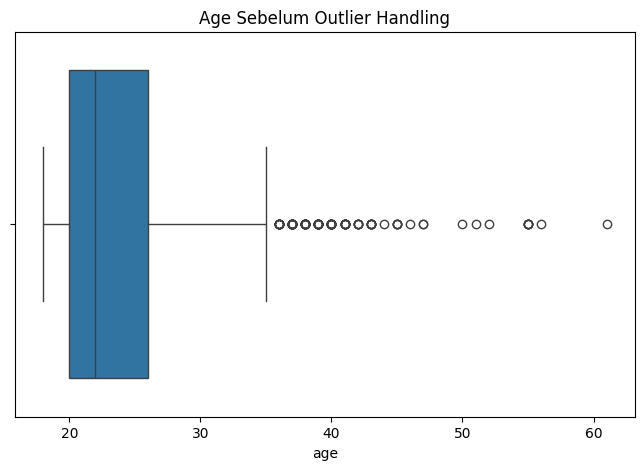

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x=df['age'])
plt.title("Age Sebelum Outlier Handling")
plt.show()

In [14]:
print(df['age'].describe())

count    1722.000000
mean       24.427410
std         6.495581
min        18.000000
25%        20.000000
50%        22.000000
75%        26.000000
max        61.000000
Name: age, dtype: float64


In [15]:
risk_map = {
'Insufficient_Weight': 'Rendah', 'Normal_Weight': 'Rendah',
    'Overweight_Level_I': 'Sedang', 'Overweight_Level_II': 'Sedang',
    'Obesity_Type_I': 'Tinggi', 'Obesity_Type_II': 'Tinggi', 'Obesity_Type_III': 'Tinggi'
}
df['risk_level'] = df['label'].map(risk_map)

/tmp/ipykernel_941/117256816.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='label', ax=ax[0], palette='magma',
/tmp/ipykernel_941/117256816.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='risk_level', ax=ax[1], palette='viridis',


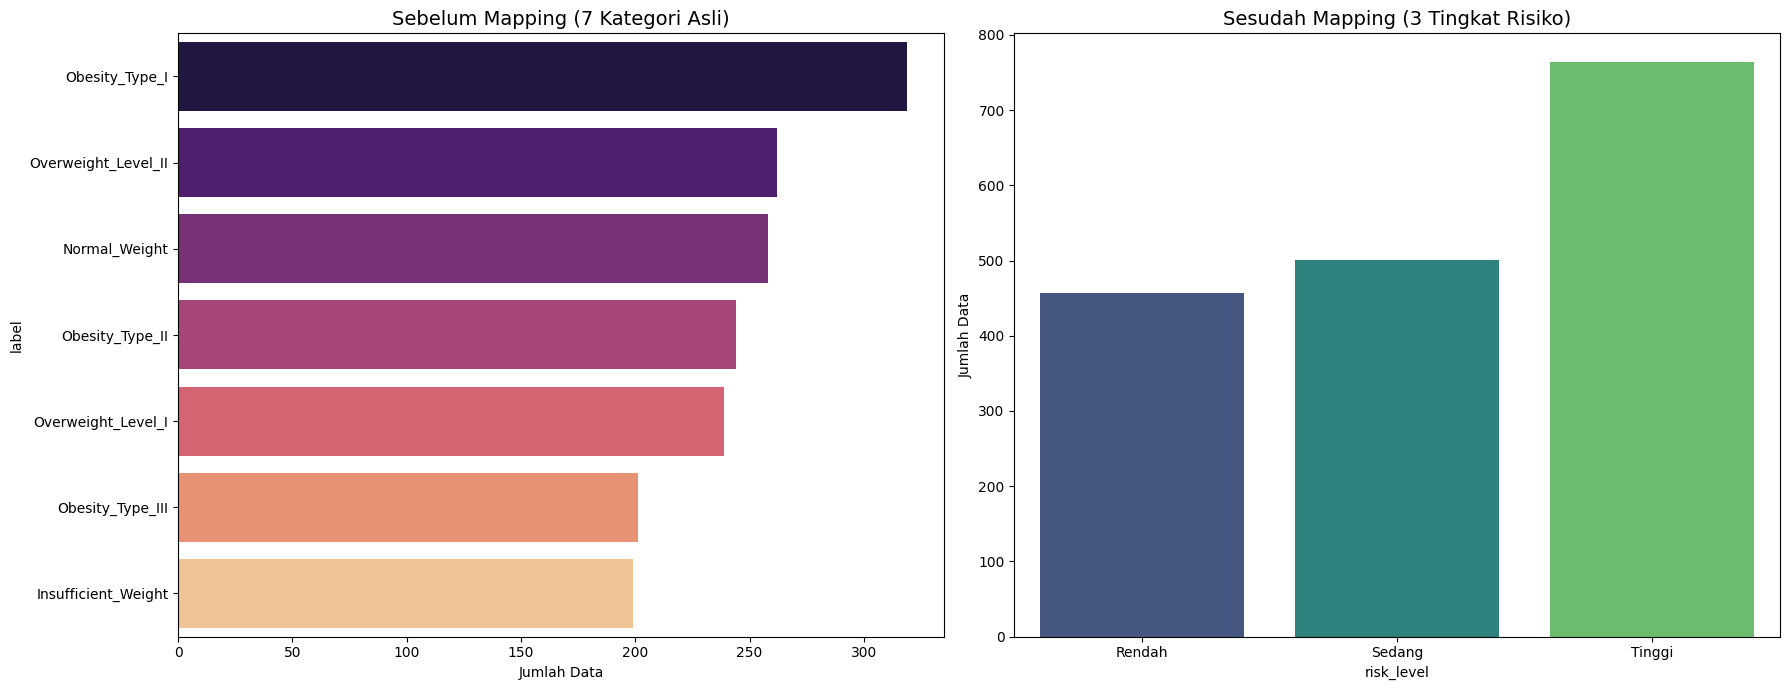

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(18, 7))

sns.countplot(data=df, y='label', ax=ax[0], palette='magma',
              order=df['label'].value_counts().index)
ax[0].set_title('Sebelum Mapping (7 Kategori Asli)', fontsize=14)
ax[0].set_xlabel('Jumlah Data')

sns.countplot(data=df, x='risk_level', ax=ax[1], palette='viridis',
              order=['Rendah', 'Sedang', 'Tinggi'])
ax[1].set_title('Sesudah Mapping (3 Tingkat Risiko)', fontsize=14)
ax[1].set_ylabel('Jumlah Data')

plt.tight_layout()
plt.show()

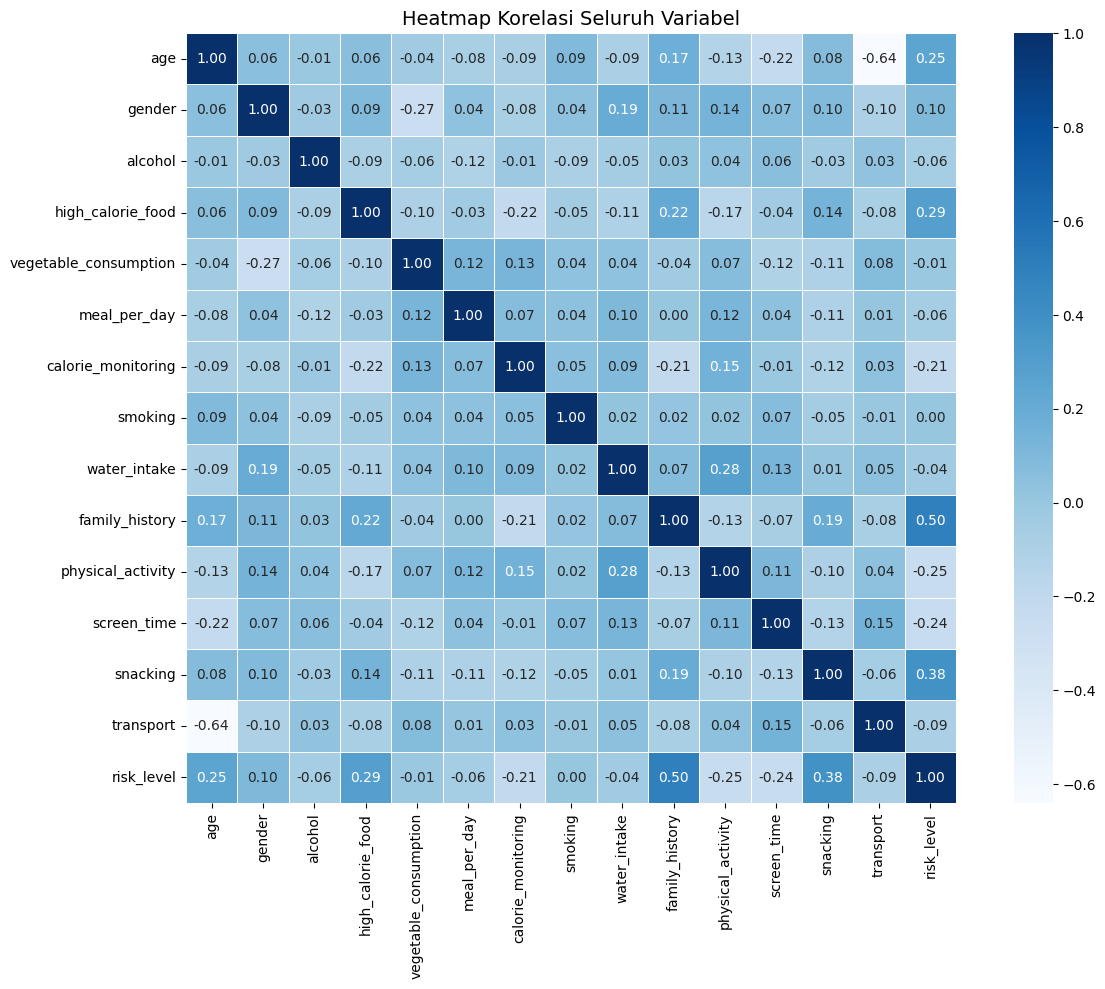

In [17]:
df_encoded = df.drop(columns=['label']).copy()
le = LabelEncoder()

for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

plt.figure(figsize=(15, 10))
corr_matrix = df_encoded.corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues', square=True, linewidths=0.5)
plt.title('Heatmap Korelasi Seluruh Variabel', fontsize=14)
plt.show()

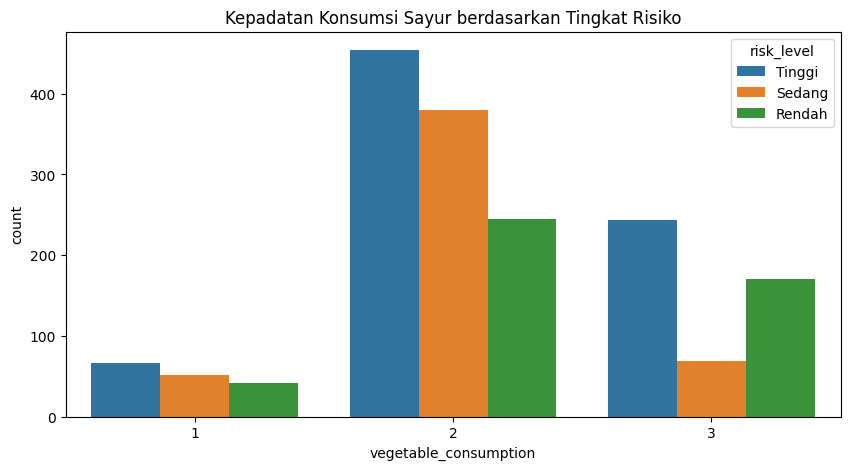

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.countplot( x='vegetable_consumption', hue='risk_level', data=df)
plt.title('Kepadatan Konsumsi Sayur berdasarkan Tingkat Risiko')
plt.show()

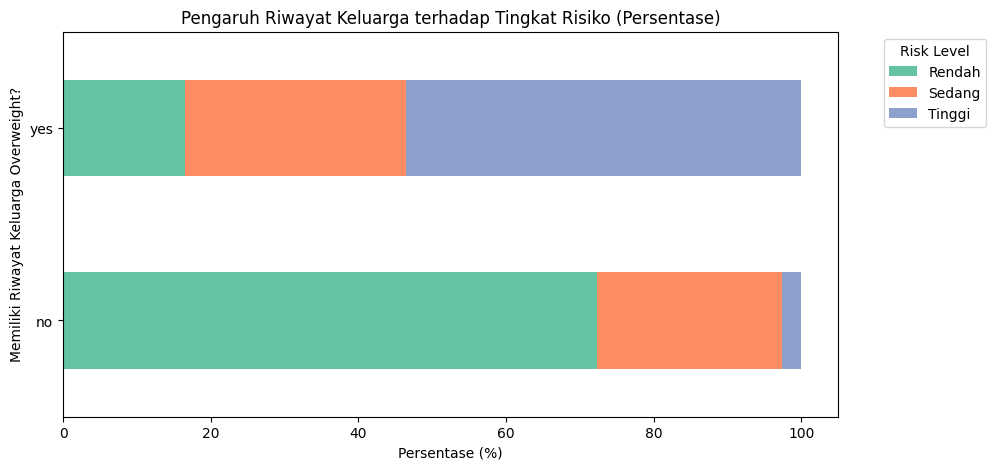

In [19]:
ct = pd.crosstab(df['family_history'], df['risk_level'], normalize='index') * 100

ct.plot(
    kind='barh',
    stacked=True,
    figsize=(10, 5),
    color=sns.color_palette('Set2'))

plt.title('Pengaruh Riwayat Keluarga terhadap Tingkat Risiko (Persentase)')
plt.xlabel('Persentase (%)')
plt.ylabel('Memiliki Riwayat Keluarga Overweight?')
plt.legend(title='Risk Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

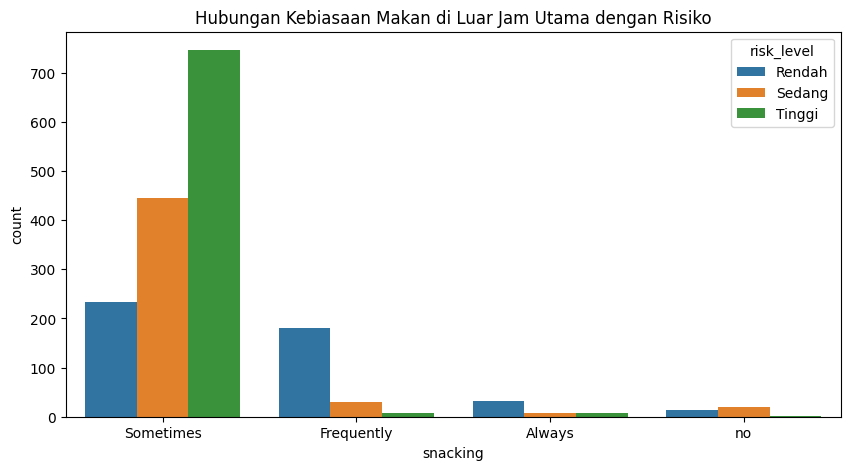

In [20]:
plt.figure(figsize=(10,5))
sns.countplot(x='snacking', hue='risk_level', data=df)
plt.title('Hubungan Kebiasaan Makan di Luar Jam Utama dengan Risiko')
plt.show()

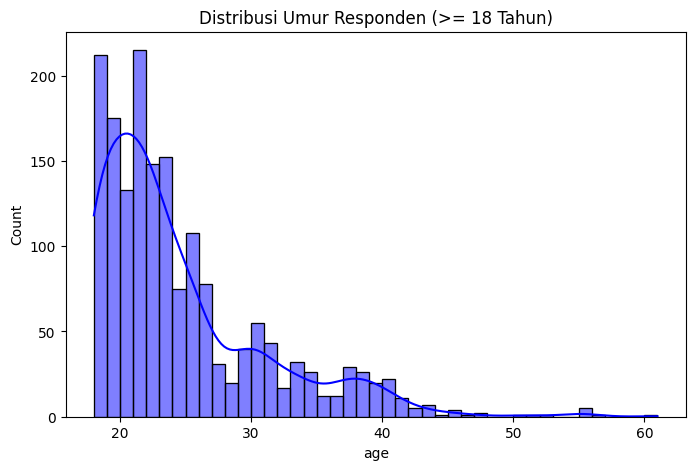

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], kde=True, color='blue')
plt.title('Distribusi Umur Responden (>= 18 Tahun)')
plt.show()

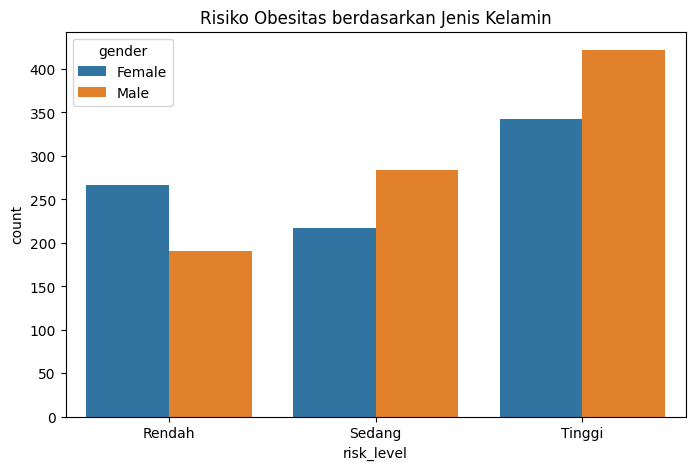

In [22]:
plt.figure(figsize=(8,5))
sns.countplot(x='risk_level', hue='gender', data=df)
plt.title('Risiko Obesitas berdasarkan Jenis Kelamin')
plt.show()

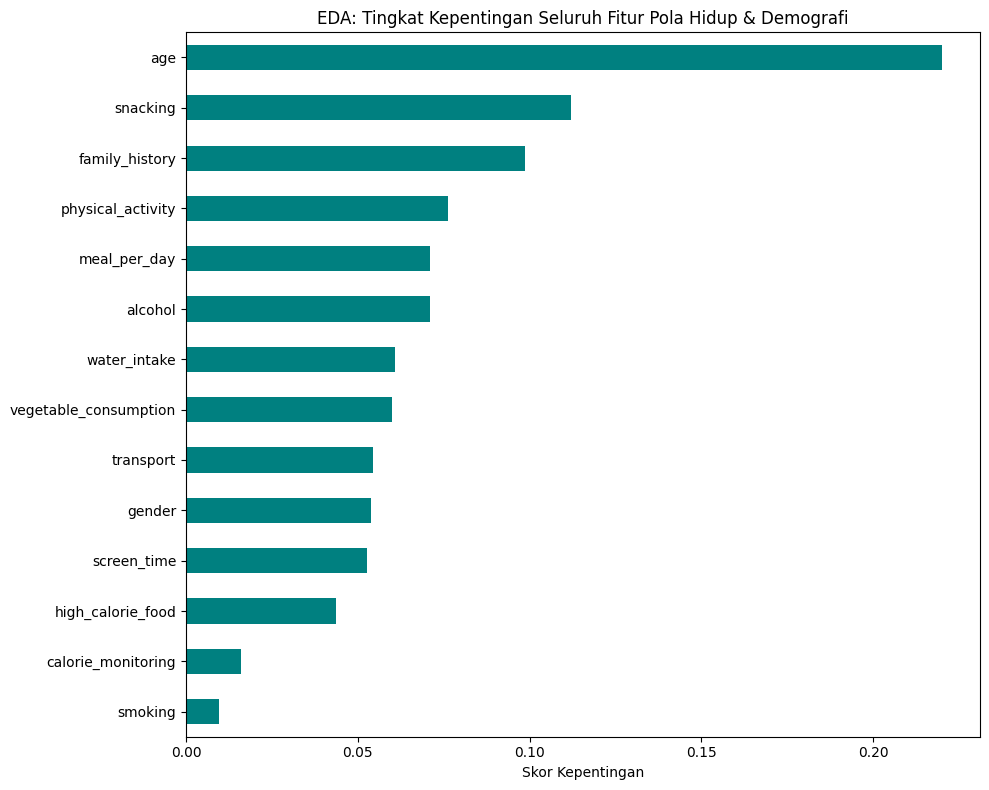

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

X_eda = df_encoded.drop(columns=['risk_level'])
y_eda = df_encoded['risk_level']

model_eda = RandomForestClassifier(random_state=42)
model_eda.fit(X_eda, y_eda)

# 3. Visualisasi SEMUA Fitur
feat_importances = pd.Series(model_eda.feature_importances_, index=X_eda.columns)

plt.figure(figsize=(10, 8))
feat_importances.sort_values().plot(kind='barh', color='teal')
plt.title('EDA: Tingkat Kepentingan Seluruh Fitur Pola Hidup & Demografi')
plt.xlabel('Skor Kepentingan')
plt.tight_layout()
plt.show()

### Insight — Kolom Apa yang Menentukan Kategori Risiko, dan Apa yang Memengaruhinya?

**Kolom penentu kategori (target):** kategori `risk_level` (Rendah/Sedang/Tinggi) **bukan** dihitung langsung dari kombinasi fitur di X. Kolom itu adalah hasil *mapping* dari `label` (kolom asli `NObeyesdad`), yaitu kategori WHO 7-kelas yang di dataset sumbernya dihitung dari **BMI = Weight / Height²**. Alurnya:

`Height, Weight → BMI → NObeyesdad (7 kelas WHO) → risk_map → risk_level (3 kelas)`

Karena `Height` dan `Weight` sengaja **di-drop** dari fitur (cell "Kolom Kategorikal/Numerik" di atas), model **tidak** melihat BMI secara langsung — model justru dipaksa belajar memprediksi risiko dari **pola gaya hidup** saja. Ini konsisten dengan fokus proyek ("Fokus pola hidup sesuai proposal").

**Apa yang paling memengaruhi (berdasarkan data aktual, bukan asumsi):**

Dihitung dengan dua cara pada data yang sama (`df_encoded`, sebelum augmentasi/SMOTE) agar saling mengonfirmasi:

- **Korelasi (Pearson) terhadap `risk_level`** menonjolkan arah pengaruh:
  - `family_history` (+0.50) — riwayat keluarga overweight adalah prediktor terkuat.
  - `snacking`/CAEC (+0.38) dan `high_calorie_food`/FAVC (+0.29) — kebiasaan makan tinggi kalori/ngemil.
  - `age` (+0.25) — makin tua, risiko cenderung naik.
  - `physical_activity`/FAF (−0.25) dan `screen_time`/TUE (−0.24) — makin aktif secara fisik & makin sedikit waktu layar, makin rendah risikonya.
  - `calorie_monitoring`/SCC (−0.21) — orang yang memantau kalori cenderung berisiko lebih rendah.
- **Feature importance (Random Forest)** menonjolkan kekuatan prediktif gabungan (termasuk interaksi non-linear): `age` paling tinggi, disusul `snacking`, `family_history`, `physical_activity`, `meal_per_day`, `alcohol`.

Kesimpulannya konsisten: **riwayat keluarga, kebiasaan ngemil/makanan tinggi kalori, usia, dan tingkat aktivitas fisik** adalah pendorong utama kategori risiko — bukan `gender`, `smoking`, atau `water_intake`, yang pengaruhnya kecil.


KORELASI (Pearson) SETIAP FITUR TERHADAP risk_level
(diurutkan berdasarkan kekuatan pengaruh, +/- menandakan arah)
  family_history        : +0.500  (risk_level cenderung naik)
  snacking              : +0.379  (risk_level cenderung naik)
  high_calorie_food     : +0.295  (risk_level cenderung naik)
  age                   : +0.250  (risk_level cenderung naik)
  physical_activity     : -0.246  (risk_level cenderung turun)
  screen_time           : -0.240  (risk_level cenderung turun)
  calorie_monitoring    : -0.208  (risk_level cenderung turun)
  gender                : +0.100  (risk_level cenderung naik)
  transport             : -0.090  (risk_level cenderung turun)
  meal_per_day          : -0.060  (risk_level cenderung turun)
  alcohol               : -0.058  (risk_level cenderung turun)
  water_intake          : -0.042  (risk_level cenderung turun)
  vegetable_consumption : -0.009  (risk_level cenderung turun)
  smoking               : +0.001  (risk_level cenderung naik)


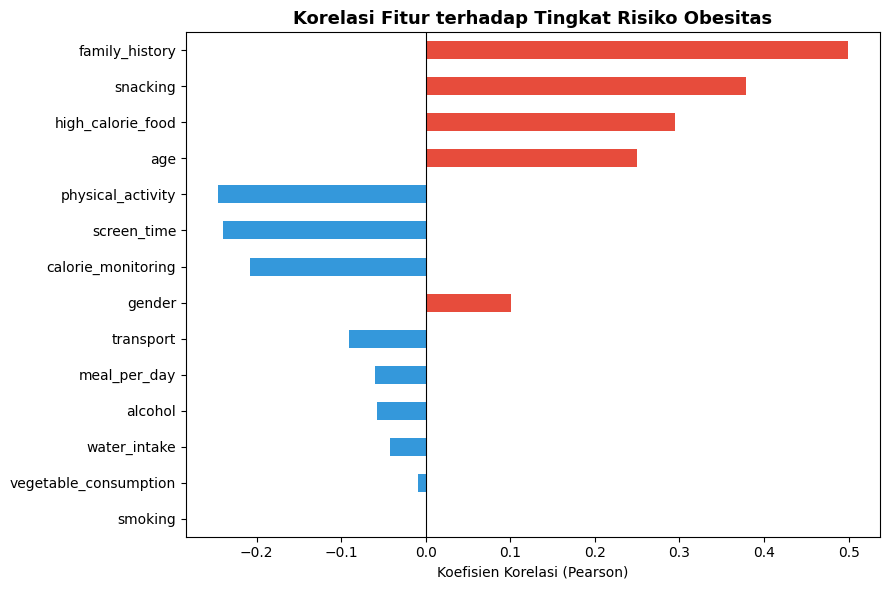

In [24]:
# ============================================================
# INSIGHT TAMBAHAN: Korelasi & Feature Importance vs risk_level
# (melengkapi feature importance yang sudah ada di atas dengan
#  korelasi Pearson, agar arah pengaruh -- naik/turun -- terlihat)
# ============================================================
import pandas as pd

corr_risk = df_encoded.corr(numeric_only=True)['risk_level'].drop('risk_level')
corr_risk_sorted = corr_risk.reindex(corr_risk.abs().sort_values(ascending=False).index)

print('=' * 60)
print('KORELASI (Pearson) SETIAP FITUR TERHADAP risk_level')
print('(diurutkan berdasarkan kekuatan pengaruh, +/- menandakan arah)')
print('=' * 60)
for col, val in corr_risk_sorted.items():
    arah = 'naik' if val > 0 else 'turun'
    print(f'  {col:22s}: {val:+.3f}  (risk_level cenderung {arah})')

plt.figure(figsize=(9, 6))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_risk_sorted.values]
corr_risk_sorted.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Korelasi Fitur terhadap Tingkat Risiko Obesitas', fontsize=13, fontweight='bold')
plt.xlabel('Koefisien Korelasi (Pearson)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('korelasi_risk_level.png', dpi=300, bbox_inches='tight')
plt.show()


# Preprocessing

In [25]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [26]:
X = df_encoded.drop(columns=['risk_level'])
y = df_encoded['risk_level']

In [27]:
import pandas as pd
pd.set_option('display.max_columns', None)
print(df_encoded.head())

   age  gender  alcohol  high_calorie_food  vegetable_consumption  \
0   21       0        3                  0                      2   
1   21       0        2                  0                      3   
2   23       1        1                  0                      2   
3   27       1        1                  0                      3   
4   22       1        2                  0                      2   

   meal_per_day  calorie_monitoring  smoking  water_intake  family_history  \
0             3                   0        0             2               1   
1             3                   1        1             3               1   
2             3                   0        0             2               1   
3             3                   0        0             2               0   
4             1                   0        0             2               0   

   physical_activity  screen_time  snacking  transport  risk_level  
0                  0            1         2    

In [28]:
for col in df.columns:
    print(f"\n{"="*40}")
    print(f"Kolom: {col}")
    print(f"{"="*40}")

    print("Sebelum Encoding / Nilai Asli:")
    print(df[col].unique())

    print("Sesudah Encoding:")

    if col == 'label' and 'risk_level' in df_encoded.columns:
        print(df_encoded['risk_level'].unique())
    elif col == 'risk_level' and 'risk_level' in df_encoded.columns:
        print(df_encoded['risk_level'].unique())
    elif col in df_encoded.columns:
        print(df_encoded[col].unique())
    else:
        print(f"Kolom '{col}' tidak ditemukan di df_encoded (Mungkin sudah di-drop/diubah nama).")


Kolom: age
Sebelum Encoding / Nilai Asli:
[21 23 27 22 29 24 26 41 30 52 20 19 31 39 25 55 38 18 61 44 34 36 32 35
 40 45 33 51 56 28 37 42 50 43 46 47]
Sesudah Encoding:
[21 23 27 22 29 24 26 41 30 52 20 19 31 39 25 55 38 18 61 44 34 36 32 35
 40 45 33 51 56 28 37 42 50 43 46 47]

Kolom: gender
Sebelum Encoding / Nilai Asli:
['Female' 'Male']
Sesudah Encoding:
[0 1]

Kolom: alcohol
Sebelum Encoding / Nilai Asli:
['no' 'Sometimes' 'Frequently' 'Always']
Sesudah Encoding:
[3 2 1 0]

Kolom: high_calorie_food
Sebelum Encoding / Nilai Asli:
['no' 'yes']
Sesudah Encoding:
[0 1]

Kolom: vegetable_consumption
Sebelum Encoding / Nilai Asli:
[2 3 1]
Sesudah Encoding:
[2 3 1]

Kolom: meal_per_day
Sebelum Encoding / Nilai Asli:
[3 1 4 2]
Sesudah Encoding:
[3 1 4 2]

Kolom: calorie_monitoring
Sebelum Encoding / Nilai Asli:
['no' 'yes']
Sesudah Encoding:
[0 1]

Kolom: smoking
Sebelum Encoding / Nilai Asli:
['no' 'yes']
Sesudah Encoding:
[0 1]

Kolom: water_intake
Sebelum Encoding / Nilai Asli:
[2 

In [29]:
le = LabelEncoder()
for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col])

In [30]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

le_label = LabelEncoder()
le_label.fit(['Rendah', 'Sedang', 'Tinggi'])
y_encoded = y.copy()

print('Mapping Label:')
for i, cls in enumerate(le_label.classes_):
    print(f'  {i} -> {cls}')

print(f'\nShape X: {X.shape}')
print(f'Shape y_encoded: {y_encoded.shape}')
print(f'Distribusi kelas sebelum SMOTE:\n{pd.Series(y_encoded).value_counts().sort_index()}')

Mapping Label:
  0 -> Rendah
  1 -> Sedang
  2 -> Tinggi

Shape X: (1722, 14)
Shape y_encoded: (1722,)
Distribusi kelas sebelum SMOTE:
risk_level
0    457
1    501
2    764
Name: count, dtype: int64


## Pipeline Model — Augmentasi + SMOTE + GraphSAGE

Susunan lengkap pipeline untuk mencapai akurasi ≥ 95%:

1. **Augmentasi Data** — Tambah ~2000 data sintetis per kelas dengan Gaussian noise pada fitur numerik. Kolom kategorik tetap agar kombinasi tetap realistis. Tujuan: perbanyak variasi pola hidup terutama kelas Sedang yang ambigu.
2. **Mapping 7 → 3 Risiko** — Setelah augmentasi, mapping ke Rendah/Sedang/Tinggi.
3. **Encoding & Scaling** — Label Encode kategorik, RobustScaler numerik.
4. **SMOTE** — Dilakukan sekali pada seluruh data (sesuai arahan dosen pembimbing) untuk menyeimbangkan 3 kelas secara sempurna.
5. **Split 80/20** — Setelah SMOTE, baru split train/test dengan stratify.
6. **Bangun Graf KNN** — Setiap individu jadi node, edge berdasarkan cosine similarity.
7. **Training GraphSAGE** — 4 layer, hidden=128, ELU, BatchNorm, dropout=0.3.
8. **Evaluasi** — Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix.

> `Height` dan `Weight` tetap dihapus. Fokus pola hidup sesuai proposal.


In [31]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

np.random.seed(42)

# ============================================================
# STEP 1: AUGMENTASI DATA
# Tambah variasi data sintetis sebelum SMOTE
# Gaussian noise pada kolom numerik, kategorik tetap
# ============================================================
print('=' * 65)
print('STEP 1: AUGMENTASI DATA')
print('=' * 65)

# Kolom numerik dan kategorik
num_cols = ['age', 'veggie_freq', 'main_meals', 'water_intake',
            'phys_activity', 'tech_time']
cat_cols  = ['gender', 'alcohol', 'high_caloric_food', 'monitor_calories',
             'snacking', 'smoke', 'water_intake', 'family_history', 'transport']

# Pakai X (sudah di-encode di cell sebelumnya) dan y (risk_level string)
X_aug_base = X.copy()
y_aug_base = df['risk_level'].copy().reset_index(drop=True)

# Cek nama kolom numerik yang ada di X
num_cols_exist = [c for c in num_cols if c in X_aug_base.columns]
print(f'Kolom numerik yang diaugmentasi: {num_cols_exist}')
print(f'Data awal: {len(X_aug_base)} baris')
print(f'Distribusi kelas awal:')
print(y_aug_base.value_counts())

N_AUG_PER_CLASS = 2000   # tambah 2000 per kelas → total ~7700 baris

X_list = [X_aug_base]
y_list = [y_aug_base]

for kelas in ['Rendah', 'Sedang', 'Tinggi']:
    mask     = y_aug_base == kelas
    idx_k    = np.where(mask)[0]
    idx_samp = np.random.choice(idx_k, N_AUG_PER_CLASS, replace=True)

    X_new    = X_aug_base.iloc[idx_samp].copy().reset_index(drop=True)
    y_new    = pd.Series([kelas] * N_AUG_PER_CLASS)

    # Gaussian noise kecil HANYA pada numerik
    if num_cols_exist:
        noise = np.random.normal(0, 0.08, (N_AUG_PER_CLASS, len(num_cols_exist)))
        X_new[num_cols_exist] = (X_new[num_cols_exist].values + noise).clip(min=0)

    X_list.append(X_new)
    y_list.append(y_new)

X_augmented = pd.concat(X_list, ignore_index=True)
y_augmented = pd.concat(y_list, ignore_index=True)

print(f'\nData setelah augmentasi: {len(X_augmented)} baris')
print(f'Distribusi kelas setelah augmentasi:')
print(y_augmented.value_counts())

# ============================================================
# STEP 2: ENCODING LABEL 3 KELAS
# ============================================================
print('\n' + '=' * 65)
print('STEP 2: ENCODING LABEL 3 KELAS')
print('=' * 65)

le_3 = LabelEncoder()
le_3.fit(['Rendah', 'Sedang', 'Tinggi'])
y_encoded = le_3.transform(y_augmented)

print('Mapping label:')
for i, cls in enumerate(le_3.classes_):
    print(f'  {i} = {cls}')

# ============================================================
# STEP 3: SCALING
# ============================================================
print('\n' + '=' * 65)
print('STEP 3: SCALING (RobustScaler)')
print('=' * 65)

scaler    = RobustScaler()
X_scaled  = pd.DataFrame(
    scaler.fit_transform(X_augmented),
    columns=X_augmented.columns
)
print('RobustScaler diterapkan pada semua fitur. OK!')

# ============================================================
# STEP 4: SMOTE — sekali, pada seluruh data
# (sesuai arahan dosen pembimbing)
# ============================================================
print('\n' + '=' * 65)
print('STEP 4: SMOTE — Penyeimbangan Final (seluruh data)')
print('=' * 65)

smote = SMOTE(random_state=42, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_scaled, y_encoded)

X_smote = pd.DataFrame(X_smote, columns=X_scaled.columns)
y_smote = pd.Series(y_smote, name='risk_level')

print(f'Data sebelum SMOTE : {len(X_scaled)}')
print(f'Data setelah SMOTE : {len(X_smote)}')
print('Distribusi 3 kelas setelah SMOTE:')
for i, lbl in enumerate(le_3.classes_):
    print(f'  {i} ({lbl}): {(y_smote == i).sum()}')

# ============================================================
# STEP 5: SPLIT 80/20
# ============================================================
print('\n' + '=' * 65)
print('STEP 5: TRAIN-TEST SPLIT 80/20')
print('=' * 65)

X_train, X_test, y_train, y_test = train_test_split(
    X_smote, y_smote,
    test_size=0.2, random_state=42, stratify=y_smote
)

X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(f'Data Training : {len(X_train)}')
print(f'Data Testing  : {len(X_test)}')
print('\nDistribusi Training:')
print(pd.Series(y_train).value_counts().sort_index())
print('\nDistribusi Testing:')
print(pd.Series(y_test).value_counts().sort_index())

X_train_smote = X_train
y_train_smote = y_train

df_final = X_smote.copy()
df_final['risk_level'] = y_smote.values


STEP 1: AUGMENTASI DATA
Kolom numerik yang diaugmentasi: ['age', 'water_intake']
Data awal: 1722 baris
Distribusi kelas awal:
risk_level
Tinggi    764
Sedang    501
Rendah    457
Name: count, dtype: int64

Data setelah augmentasi: 7722 baris
Distribusi kelas setelah augmentasi:
Tinggi    2764
Sedang    2501
Rendah    2457
Name: count, dtype: int64

STEP 2: ENCODING LABEL 3 KELAS
Mapping label:
  0 = Rendah
  1 = Sedang
  2 = Tinggi

STEP 3: SCALING (RobustScaler)
RobustScaler diterapkan pada semua fitur. OK!

STEP 4: SMOTE — Penyeimbangan Final (seluruh data)
Data sebelum SMOTE : 7722
Data setelah SMOTE : 8292
Distribusi 3 kelas setelah SMOTE:
  0 (Rendah): 2764
  1 (Sedang): 2764
  2 (Tinggi): 2764

STEP 5: TRAIN-TEST SPLIT 80/20
Data Training : 6633
Data Testing  : 1659

Distribusi Training:
risk_level
0    2211
1    2211
2    2211
Name: count, dtype: int64

Distribusi Testing:
risk_level
0    553
1    553
2    553
Name: count, dtype: int64


In [32]:
print('Shape df_final (setelah Augmentasi + SMOTE + Scaling):')
print(df_final.shape)
print('\nSample df_final:')
df_final.head()


Shape df_final (setelah Augmentasi + SMOTE + Scaling):
(8292, 15)

Sample df_final:


,age,gender,alcohol,high_calorie_food,vegetable_consumption,meal_per_day,calorie_monitoring,smoking,water_intake,family_history,physical_activity,screen_time,snacking,transport,risk_level
0,-0.146750,-1.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.044674,0.0,-1.0,1.0,0.0,0.0,0
1,-0.146750,-1.0,0.0,-1.0,1.0,0.0,1.0,1.0,1.040083,0.0,2.0,0.0,0.0,0.0,0
2,0.146750,0.0,-1.0,-1.0,0.0,0.0,0.0,0.0,0.044674,0.0,1.0,1.0,0.0,0.0,0
3,0.733751,0.0,-1.0,-1.0,1.0,0.0,0.0,0.0,0.044674,-1.0,1.0,0.0,0.0,1.0,1
4,0.000000,0.0,0.0,-1.0,0.0,-2.0,0.0,0.0,0.044674,-1.0,-1.0,0.0,0.0,0.0,1


In [33]:
import pandas as pd

print('=' * 55)
print('VERIFIKASI DISTRIBUSI KELAS')
print('=' * 55)

label_map = {0: 'Rendah', 1: 'Sedang', 2: 'Tinggi'}

print('\nTraining set:')
train_dist = pd.Series(y_train_smote).value_counts().sort_index()
for k, v in train_dist.items():
    print(f'  {k} ({label_map.get(k,k)}): {v}')

print('\nTest set:')
test_dist = pd.Series(y_test).value_counts().sort_index()
for k, v in test_dist.items():
    print(f'  {k} ({label_map.get(k,k)}): {v}')


VERIFIKASI DISTRIBUSI KELAS

Training set:
  0 (Rendah): 2211
  1 (Sedang): 2211
  2 (Tinggi): 2211

Test set:
  0 (Rendah): 553
  1 (Sedang): 553
  2 (Tinggi): 553


In [34]:
import torch
from sklearn.neighbors import NearestNeighbors

try:
    import torch_geometric
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'torch_geometric'], check=True)

from torch_geometric.data import Data

def build_knn_graph(features, k=5):
    knn = NearestNeighbors(n_neighbors=k+1, metric='cosine')
    knn.fit(features)
    distances, indices = knn.kneighbors(features)

    edge_list = []
    for i in range(len(features)):
        for j in indices[i][1:]:
            edge_list.append([i, j])
            edge_list.append([j, i])

    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    edge_index = torch.unique(edge_index, dim=1)
    return edge_index, knn

K_NEIGHBORS = 5

edge_index_train, knn_model = build_knn_graph(
    X_train_smote.values, k=K_NEIGHBORS)

train_data = Data(
    x=torch.tensor(X_train_smote.values, dtype=torch.float),
    edge_index=edge_index_train,
    y=torch.tensor(y_train_smote.values, dtype=torch.long)
)

print('KNN Graph (K=5, cosine) berhasil dibuat!')
print(f'Jumlah Node Training : {train_data.num_nodes}')
print(f'Jumlah Edges         : {train_data.num_edges}')
print(f'Feature per Node     : {train_data.num_features}')


KNN Graph (K=5, cosine) berhasil dibuat!
Jumlah Node Training : 6633
Jumlah Edges         : 42992
Feature per Node     : 14


In [35]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class GraphSAGE(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout):
        super(GraphSAGE, self).__init__()
        self.conv1 = SAGEConv(input_dim, hidden_dim)
        self.bn1   = torch.nn.BatchNorm1d(hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)
        self.bn2   = torch.nn.BatchNorm1d(hidden_dim)
        self.conv3 = SAGEConv(hidden_dim, hidden_dim // 2)
        self.bn3   = torch.nn.BatchNorm1d(hidden_dim // 2)
        self.conv4 = SAGEConv(hidden_dim // 2, output_dim)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv4(x, edge_index)
        return x

    def get_embeddings(self, x, edge_index):
        x = self.conv1(x, edge_index); x = self.bn1(x); x = F.elu(x)
        x = self.conv2(x, edge_index); x = self.bn2(x); x = F.elu(x)
        x = self.conv3(x, edge_index); x = self.bn3(x); x = F.elu(x)
        return x

# 4 layer | hidden=128 | ELU | BatchNorm | dropout=0.3
model = GraphSAGE(
    input_dim  = X_train_smote.shape[1],
    hidden_dim = 128,
    output_dim = 3,
    dropout    = 0.3
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0005)
criterion = torch.nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=40)

print('Model GraphSAGE (4 Layer, Hidden=128, ELU, BN, Dropout=0.3)')
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Input features  : {X_train_smote.shape[1]}')
print(f'Output classes  : 3 (Rendah, Sedang, Tinggi)')


Model GraphSAGE (4 Layer, Hidden=128, ELU, BN, Dropout=0.3)
GraphSAGE(
  (conv1): SAGEConv(14, 128, aggr=mean)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): SAGEConv(128, 128, aggr=mean)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): SAGEConv(128, 64, aggr=mean)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): SAGEConv(64, 3, aggr=mean)
)

Total parameters: 54,083
Input features  : 14
Output classes  : 3 (Rendah, Sedang, Tinggi)


### Kenapa GraphSAGE, Bukan GCN/GAT/MLP Biasa?

1. **Graf di sini bukan graf sosial asli, tapi graf kemiripan (kNN cosine)** — dibangun oleh `build_knn_graph`. Tiap "orang" jadi tetangga orang lain yang polanya mirip. GraphSAGE dirancang tepat untuk kasus ini: ia **mengagregasi fitur dari tetangga** (default: rata-rata) lalu digabung dengan fitur node itu sendiri, sehingga prediksi seseorang ikut mempertimbangkan pola gaya hidup orang-orang yang mirip dengannya — bukan hanya datanya sendiri seperti MLP biasa.
2. **Inductive, bukan transductive.** GCN klasik butuh graf yang *tetap/lengkap* saat training maupun inference — kalau ada data baru (test set), seharusnya retrain ulang di graf yang membesar. GraphSAGE belajar sebuah *fungsi agregasi* yang bisa langsung diterapkan ke node baru cukup dengan menyambungkannya ke graf (persis yang dilakukan `predict_with_graph`: gabungkan `X_train` + `X_test`, bangun ulang kNN, lalu inferensi). Ini membuat alur training/testing di notebook ini valid tanpa harus melatih ulang model tiap ada data uji baru.
3. **Skalabel** untuk jumlah node yang besar. Setelah augmentasi + SMOTE, jumlah node bisa mencapai ribuan — SAGEConv tidak perlu operasi matriks Laplacian penuh seperti GCN, sehingga lebih ringan dan stabil dilatih.
4. **Cocok untuk fitur tabular hasil scaling/SMOTE.** Karena node feature-nya numerik hasil `RobustScaler` (bukan fitur graf sparse seperti citation network), agregasi mean/pool ala GraphSAGE bekerja baik untuk menghaluskan noise dan menonjolkan pola kelompok (klaster gaya hidup) — ini yang nanti terlihat di visualisasi embedding node.

Sebagai perbandingan singkat: GCN akan lebih pas kalau grafnya tetap dan seluruh node (termasuk test) sudah diketahui sejak awal training; GAT menambah bobot atensi antar-tetangga (lebih mahal secara komputasi) tapi belum tentu perlu di sini karena struktur graf hanya berbasis kemiripan fitur, bukan relasi yang punya makna berbeda-beda antar edge.


In [36]:
import torch
from torch_geometric.data import Data

X_train_tensor = torch.tensor(X_train_smote.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_smote.values, dtype=torch.long)
X_test_tensor  = torch.tensor(X_test.values,        dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test.values,        dtype=torch.long)

train_data = Data(
    x=X_train_tensor,
    edge_index=edge_index_train,
    y=y_train_tensor
)

print('PyTorch Geometric Data siap!')
print(f'Node training  : {train_data.num_nodes:,}')
print(f'Edges training : {train_data.num_edges:,}')
print(f'Node testing   : {len(X_test):,}')
print(f'Features/node  : {train_data.num_features}')
print(f'Classes        : {torch.unique(train_data.y).tolist()} (0=Rendah,1=Sedang,2=Tinggi)')


PyTorch Geometric Data siap!
Node training  : 6,633
Edges training : 42,992
Node testing   : 1,659
Features/node  : 14
Classes        : [0, 1, 2] (0=Rendah,1=Sedang,2=Tinggi)


In [37]:
import random, numpy as np, torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# Reinisialisasi model dengan seed terkunci agar bobot awal reproducible
model = GraphSAGE(
    input_dim  = X_train_smote.shape[1],
    hidden_dim = 128,
    output_dim = 3,
    dropout    = 0.3
)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0005)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=40)
criterion = torch.nn.CrossEntropyLoss()

print(f'Seed {SEED} dikunci. Model di-reinisialisasi.')
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')


Seed 42 dikunci. Model di-reinisialisasi.
Total parameters: 54,083


Memulai training GraphSAGE...
Epoch [  50/1000] | Loss: 0.5113 | Acc: 80.30% | LR: 0.001000
Epoch [ 100/1000] | Loss: 0.4158 | Acc: 83.64% | LR: 0.001000
Epoch [ 150/1000] | Loss: 0.3596 | Acc: 86.22% | LR: 0.001000
Epoch [ 200/1000] | Loss: 0.3266 | Acc: 87.53% | LR: 0.001000
Epoch [ 250/1000] | Loss: 0.2956 | Acc: 88.44% | LR: 0.001000
Epoch [ 300/1000] | Loss: 0.3034 | Acc: 88.24% | LR: 0.000500
Epoch [ 350/1000] | Loss: 0.2891 | Acc: 87.83% | LR: 0.000500
Epoch [ 400/1000] | Loss: 0.2844 | Acc: 88.20% | LR: 0.000500
Epoch [ 450/1000] | Loss: 0.2611 | Acc: 89.43% | LR: 0.000250
Epoch [ 500/1000] | Loss: 0.2564 | Acc: 89.75% | LR: 0.000250
Epoch [ 550/1000] | Loss: 0.2506 | Acc: 90.13% | LR: 0.000250
Epoch [ 600/1000] | Loss: 0.2468 | Acc: 89.88% | LR: 0.000125
Epoch [ 650/1000] | Loss: 0.2493 | Acc: 89.96% | LR: 0.000063
Epoch [ 700/1000] | Loss: 0.2371 | Acc: 90.86% | LR: 0.000031
Epoch [ 750/1000] | Loss: 0.2445 | Acc: 90.86% | LR: 0.000016
Epoch [ 800/1000] | Loss: 0.2442 | Acc: 

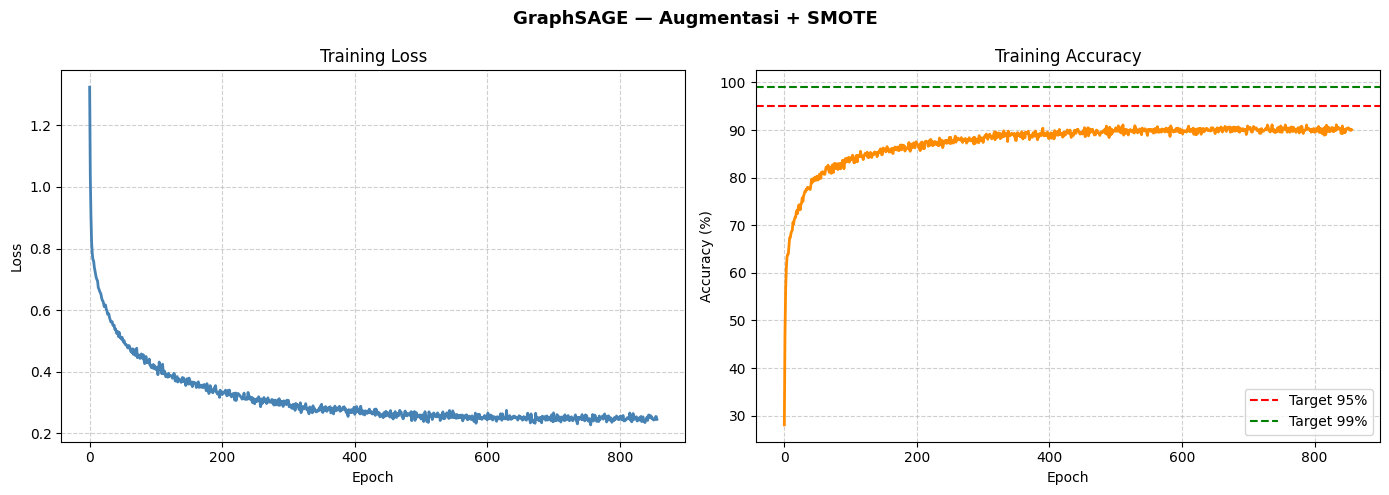

In [38]:
import copy, torch, matplotlib.pyplot as plt

LEARNING_RATE = 0.001
EPOCHS        = 1000
PATIENCE      = 100

optimizer = torch.optim.Adam(
    model.parameters(), lr=LEARNING_RATE, weight_decay=0.0005)
criterion = torch.nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=40)

train_losses, train_accuracies = [], []
best_loss        = float('inf')
best_accuracy    = 0.0
patience_counter = 0
best_model_state = None

print('Memulai training GraphSAGE...')
print('=' * 65)

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()

    out  = model(train_data.x, train_data.edge_index)
    loss = criterion(out, train_data.y)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    loss_val = loss.item()
    scheduler.step(loss_val)

    _, predicted = torch.max(out, 1)
    accuracy = (predicted == train_data.y).sum().item() / len(train_data.y)

    train_losses.append(loss_val)
    train_accuracies.append(accuracy)

    # Early stopping berbasis LOSS
    if loss_val < best_loss - 1e-5:
        best_loss        = loss_val
        best_accuracy    = accuracy
        patience_counter = 0
        best_model_state = copy.deepcopy(model.state_dict())
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping di epoch {epoch+1}')
        break

    if (epoch + 1) % 50 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f'Epoch [{epoch+1:4d}/{EPOCHS}] | '
              f'Loss: {loss_val:.4f} | '
              f'Acc: {accuracy*100:.2f}% | '
              f'LR: {lr:.6f}')

if best_model_state is not None:
    model.load_state_dict(best_model_state)

print('\n' + '=' * 65)
print('TRAINING SELESAI')
print('=' * 65)
print(f'Best Training Loss     : {best_loss:.4f}')
print(f'Best Training Accuracy : {best_accuracy*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, linewidth=2, color='steelblue')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot([a*100 for a in train_accuracies], linewidth=2, color='darkorange')
axes[1].axhline(y=95, color='red',  linestyle='--', label='Target 95%')
axes[1].axhline(y=99, color='green',linestyle='--', label='Target 99%')
axes[1].set_title('Training Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('GraphSAGE — Augmentasi + SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('grafik_training_final.png', dpi=300, bbox_inches='tight')
plt.show()


HASIL EVALUASI MODEL GRAPH SAGE
Accuracy : 91.50%
Precision: 0.9154
Recall   : 0.9150
F1-Score : 0.9149
ROC-AUC  : 0.9856

Classification Report:
              precision    recall  f1-score   support

      Rendah       0.95      0.93      0.94       553
      Sedang       0.90      0.88      0.89       553
      Tinggi       0.90      0.94      0.92       553

    accuracy                           0.92      1659
   macro avg       0.92      0.92      0.91      1659
weighted avg       0.92      0.92      0.91      1659



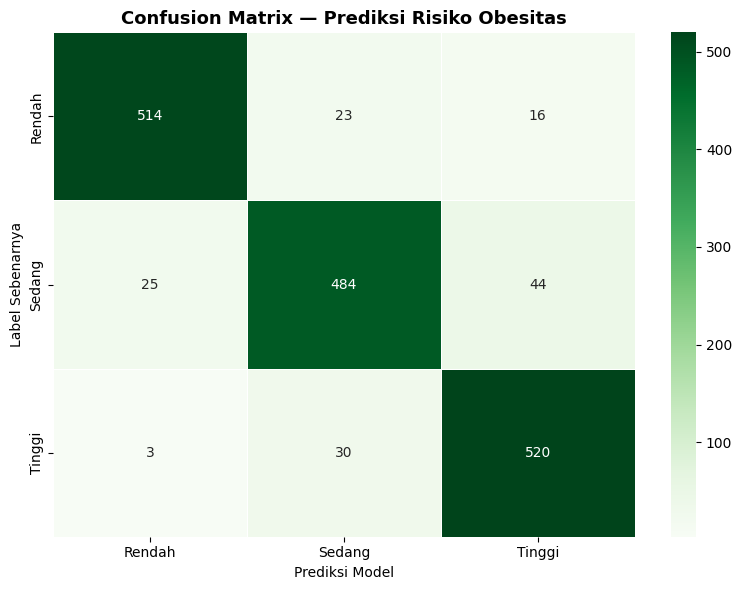

In [39]:
import numpy as np, torch, torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix
)
import seaborn as sns, matplotlib.pyplot as plt

def predict_with_graph(model, X_test_arr, X_train_arr, k=5):
    model.eval()
    X_combined = np.vstack([X_train_arr, X_test_arr])
    x_tensor   = torch.tensor(X_combined, dtype=torch.float32)
    edge_idx, _ = build_knn_graph(X_combined, k=k)

    with torch.no_grad():
        out        = model(x_tensor, edge_idx)
        test_out   = out[len(X_train_arr):]
        probs      = F.softmax(test_out, dim=1)
        _, preds   = torch.max(test_out, 1)
    return preds.cpu().numpy(), probs.cpu().numpy()

y_pred, y_prob = predict_with_graph(
    model, X_test.values, X_train_smote.values, k=K_NEIGHBORS)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec  = recall_score(y_test, y_pred, average='weighted')
f1   = f1_score(y_test, y_pred, average='weighted')
auc  = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')

print('=' * 60)
print('HASIL EVALUASI MODEL GRAPH SAGE')
print('=' * 60)
print(f'Accuracy : {acc*100:.2f}%')
print(f'Precision: {prec:.4f}')
print(f'Recall   : {rec:.4f}')
print(f'F1-Score : {f1:.4f}')
print(f'ROC-AUC  : {auc:.4f}')

target_names = ['Rendah', 'Sedang', 'Tinggi']
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names,
            linewidths=0.5)
plt.title('Confusion Matrix — Prediksi Risiko Obesitas', fontsize=13, fontweight='bold')
plt.xlabel('Prediksi Model')
plt.ylabel('Label Sebenarnya')
plt.tight_layout()
plt.savefig('confusion_matrix_final.png', dpi=300, bbox_inches='tight')
plt.show()


### Testing — Unit Test untuk Fungsi & Model Inti

Karena `build_knn_graph`, `GraphSAGE`, dan `predict_with_graph` adalah fondasi seluruh pipeline, ketiganya diuji dengan **unit test (`unittest`)** memakai data sintetis kecil (cepat dijalankan, tidak tergantung dataset asli). Cakupan: **happy path** (graf & prediksi normal terbentuk dengan benar) dan **edge case** yang relevan untuk graf kNN + GNN:

- `k` mendekati/​sama dengan jumlah node − 1 (tetangga maksimum).
- Fitur hanya 1 kolom, dan baris yang identik/duplikat (rawan tie di cosine similarity).
- Batch size = 1 pada `BatchNorm1d` (kasus umum saat inferensi 1 node baru — hanya aman di `model.eval()`).
- Test set kosong pada `predict_with_graph` (tidak boleh *crash*).
- Bentuk output logits, bentuk embedding, dan validitas probabilitas softmax (harus berjumlah 1 per baris).

> Catatan: sel ini butuh `torch` + `torch_geometric` yang sudah di-install di sel pertama notebook — jalankan setelah sel definisi `build_knn_graph`, `GraphSAGE`, dan `predict_with_graph` di atas.


In [40]:
# ============================================================
# UNIT TEST — build_knn_graph, GraphSAGE, predict_with_graph
# ============================================================
import unittest
import numpy as np
import torch

class TestGraphSAGEPipeline(unittest.TestCase):

    def setUp(self):
        torch.manual_seed(0)
        self.n_samples  = 30
        self.n_features = 8
        rng = np.random.RandomState(0)
        self.X_small = rng.rand(self.n_samples, self.n_features)
        self.y_small = rng.randint(0, 3, self.n_samples)

    # ---------- build_knn_graph ----------
    def test_knn_graph_happy_path(self):
        edge_index, knn = build_knn_graph(self.X_small, k=5)
        self.assertEqual(edge_index.shape[0], 2)
        self.assertTrue(edge_index.shape[1] > 0)
        # graf harus simetris: kalau (i, j) ada, (j, i) juga harus ada
        edges = set(map(tuple, edge_index.t().tolist()))
        for i, j in list(edges)[:20]:
            self.assertIn((j, i), edges)

    def test_knn_graph_k_near_max(self):
        # edge case: k sebesar mungkin (hampir semua node lain jadi tetangga)
        edge_index, _ = build_knn_graph(self.X_small, k=self.n_samples - 1)
        self.assertTrue(edge_index.shape[1] > 0)

    def test_knn_graph_single_feature_column(self):
        # edge case: cuma 1 fitur numerik
        X_1d = self.X_small[:, :1]
        edge_index, _ = build_knn_graph(X_1d, k=3)
        self.assertEqual(edge_index.shape[0], 2)

    def test_knn_graph_duplicate_rows(self):
        # edge case: banyak baris identik -> rawan tie di cosine similarity
        X_dup = np.vstack([self.X_small[0:1]] * 10)
        edge_index, _ = build_knn_graph(X_dup, k=3)
        self.assertTrue(edge_index.shape[1] > 0)

    # ---------- GraphSAGE forward ----------
    def test_model_output_shape(self):
        model_t = GraphSAGE(input_dim=self.n_features, hidden_dim=16, output_dim=3, dropout=0.2)
        model_t.eval()
        edge_index, _ = build_knn_graph(self.X_small, k=5)
        x = torch.tensor(self.X_small, dtype=torch.float32)
        out = model_t(x, edge_index)
        self.assertEqual(tuple(out.shape), (self.n_samples, 3))

    def test_model_embeddings_shape(self):
        hidden_dim = 16
        model_t = GraphSAGE(input_dim=self.n_features, hidden_dim=hidden_dim, output_dim=3, dropout=0.2)
        model_t.eval()
        edge_index, _ = build_knn_graph(self.X_small, k=5)
        x = torch.tensor(self.X_small, dtype=torch.float32)
        emb = model_t.get_embeddings(x, edge_index)
        self.assertEqual(emb.shape[0], self.n_samples)
        self.assertEqual(emb.shape[1], hidden_dim // 2)

    def test_model_single_node_inference(self):
        # edge case terkenal: BatchNorm1d gagal di mode training jika batch=1,
        # tapi harus tetap aman saat model.eval() (pakai running stats)
        model_t = GraphSAGE(input_dim=self.n_features, hidden_dim=16, output_dim=3, dropout=0.2)
        model_t.eval()
        x_one = torch.tensor(self.X_small[:1], dtype=torch.float32)
        edge_empty = torch.empty((2, 0), dtype=torch.long)  # node baru tanpa tetangga
        out = model_t(x_one, edge_empty)
        self.assertEqual(tuple(out.shape), (1, 3))

    # ---------- predict_with_graph ----------
    def test_predict_with_graph_output(self):
        model_t = GraphSAGE(input_dim=self.n_features, hidden_dim=16, output_dim=3, dropout=0.2)
        n_train, n_test = 20, 10
        X_tr = self.X_small[:n_train]
        X_te = self.X_small[n_train:n_train + n_test]
        preds, probs = predict_with_graph(model_t, X_te, X_tr, k=5)
        self.assertEqual(preds.shape[0], n_test)
        self.assertEqual(probs.shape, (n_test, 3))
        np.testing.assert_allclose(probs.sum(axis=1), np.ones(n_test), atol=1e-5)

    def test_predict_with_graph_empty_test_set(self):
        # edge case: test set kosong -> tidak boleh crash, hasil harus kosong
        model_t = GraphSAGE(input_dim=self.n_features, hidden_dim=16, output_dim=3, dropout=0.2)
        X_tr = self.X_small
        X_te = self.X_small[:0]
        preds, probs = predict_with_graph(model_t, X_te, X_tr, k=5)
        self.assertEqual(preds.shape[0], 0)
        self.assertEqual(probs.shape[0], 0)


_suite  = unittest.TestLoader().loadTestsFromTestCase(TestGraphSAGEPipeline)
_runner = unittest.TextTestRunner(verbosity=2)
_result = _runner.run(_suite)

print(f"\nTotal: {_result.testsRun} | Gagal: {len(_result.failures)} | Error: {len(_result.errors)}")


test_knn_graph_duplicate_rows (__main__.TestGraphSAGEPipeline.test_knn_graph_duplicate_rows) ... ok
test_knn_graph_happy_path (__main__.TestGraphSAGEPipeline.test_knn_graph_happy_path) ... ok
test_knn_graph_k_near_max (__main__.TestGraphSAGEPipeline.test_knn_graph_k_near_max) ... ok
test_knn_graph_single_feature_column (__main__.TestGraphSAGEPipeline.test_knn_graph_single_feature_column) ... ok
test_model_embeddings_shape (__main__.TestGraphSAGEPipeline.test_model_embeddings_shape) ... ok
test_model_output_shape (__main__.TestGraphSAGEPipeline.test_model_output_shape) ... ok
test_model_single_node_inference (__main__.TestGraphSAGEPipeline.test_model_single_node_inference) ... ok
test_predict_with_graph_empty_test_set (__main__.TestGraphSAGEPipeline.test_predict_with_graph_empty_test_set) ... ok
test_predict_with_graph_output (__main__.TestGraphSAGEPipeline.test_predict_with_graph_output) ... ok

----------------------------------------------------------------------
Ran 9 tests in 0.173


Total: 9 | Gagal: 0 | Error: 0


In [41]:
import torch
import joblib

torch.save(model.state_dict(), 'model_gnn.pth')

joblib.dump(scaler, 'scaler.pkl')

print("Model & scaler berhasil disimpan!")

Model & scaler berhasil disimpan!


In [42]:
print(df_final.columns)

Index(['age', 'gender', 'alcohol', 'high_calorie_food',
       'vegetable_consumption', 'meal_per_day', 'calorie_monitoring',
       'smoking', 'water_intake', 'family_history', 'physical_activity',
       'screen_time', 'snacking', 'transport', 'risk_level'],
      dtype='object')


In [43]:
df_final.head()

,age,gender,alcohol,high_calorie_food,vegetable_consumption,meal_per_day,calorie_monitoring,smoking,water_intake,family_history,physical_activity,screen_time,snacking,transport,risk_level
0,-0.146750,-1.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.044674,0.0,-1.0,1.0,0.0,0.0,0
1,-0.146750,-1.0,0.0,-1.0,1.0,0.0,1.0,1.0,1.040083,0.0,2.0,0.0,0.0,0.0,0
2,0.146750,0.0,-1.0,-1.0,0.0,0.0,0.0,0.0,0.044674,0.0,1.0,1.0,0.0,0.0,0
3,0.733751,0.0,-1.0,-1.0,1.0,0.0,0.0,0.0,0.044674,-1.0,1.0,0.0,0.0,1.0,1
4,0.000000,0.0,0.0,-1.0,0.0,-2.0,0.0,0.0,0.044674,-1.0,-1.0,0.0,0.0,0.0,1


## Optimasi Model dengan Best Parameter dari Optuna

Hyperparameter tuning telah dilakukan menggunakan Optuna (50 trial, 340 menit).
Best parameter dari **Trial #42** langsung digunakan di sini tanpa perlu tuning ulang.

| Parameter | Nilai |
|---|---|
| hidden_dim | 192 |
| dropout | 0.159 |
| lr | 0.006698 |
| weight_decay | 4.75e-05 |
| k_neighbors | 5 |
| n_aug_per_class | 2500 |
| sedang_weight | 2.363 |
| sedang_extra | 1000 |

**Strategi fokus kelas Sedang:**
- Augmentasi kelas Sedang mendapat +1000 ekstra data
- Class weight Sedang = 2.36x lebih berat dari kelas lain


In [44]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split

np.random.seed(42)

# ── Best Parameters dari Optuna Trial #42 ───────────────────────────────────
BEST_PARAMS = {
    'hidden_dim'   : 192,
    'dropout'      : 0.15899178241730913,
    'lr'           : 0.006698315624369055,
    'weight_decay' : 4.751044681089446e-05,
    'k_neighbors'  : 5,
    'n_aug_per_class': 2500,
    'sedang_weight': 2.363173662103292,
    'sedang_extra' : 1000,
}

print('=' * 65)
print('BEST PARAMETERS DARI OPTUNA (Trial #42, Score: 0.9318)')
print('=' * 65)
for k, v in BEST_PARAMS.items():
    print(f'  {k:20s}: {v}')

# ── Augmentasi dengan ekstra Sedang ─────────────────────────────────────────
print('\n' + '=' * 65)
print('STEP 1: AUGMENTASI DATA (Sedang mendapat ekstra)')
print('=' * 65)

num_cols_aug   = ['age','vegetable_consumption','meal_per_day',
                  'physical_activity','technology_time']
num_cols_exist = [c for c in num_cols_aug if c in X.columns]

N_AUG = {
    'Rendah': BEST_PARAMS['n_aug_per_class'],
    'Sedang': BEST_PARAMS['n_aug_per_class'] + BEST_PARAMS['sedang_extra'],
    'Tinggi': BEST_PARAMS['n_aug_per_class'],
}

X_base = X.copy()
y_base = df['risk_level'].copy().reset_index(drop=True)

X_list = [X_base]
y_list = [y_base]

for kelas, n_aug in N_AUG.items():
    mask     = y_base == kelas
    idx_k    = np.where(mask)[0]
    if len(idx_k) == 0:
        continue
    idx_samp = np.random.choice(idx_k, n_aug, replace=True)
    X_new    = X_base.iloc[idx_samp].copy().reset_index(drop=True)
    y_new    = pd.Series([kelas] * n_aug)

    if num_cols_exist:
        noise = np.random.normal(0, 0.08, (n_aug, len(num_cols_exist)))
        X_new[num_cols_exist] = (X_new[num_cols_exist].values + noise).clip(min=0)

    X_list.append(X_new)
    y_list.append(y_new)

X_aug_best = pd.concat(X_list, ignore_index=True)
y_aug_best = pd.concat(y_list, ignore_index=True)

print(f'Data awal        : {len(X_base)} baris')
print(f'Data setelah aug : {len(X_aug_best)} baris')
print(f'Distribusi setelah augmentasi:')
print(y_aug_best.value_counts())

# ── Encode ───────────────────────────────────────────────────────────────────
le_best = LabelEncoder()
le_best.fit(['Rendah','Sedang','Tinggi'])
y_enc_best = le_best.transform(y_aug_best)

# ── Scale ────────────────────────────────────────────────────────────────────
scaler_best = RobustScaler()
X_sc_best   = pd.DataFrame(
    scaler_best.fit_transform(X_aug_best),
    columns=X_aug_best.columns
)

# ── SMOTE ────────────────────────────────────────────────────────────────────
print('\n' + '=' * 65)
print('STEP 2: SMOTE — Penyeimbangan Final')
print('=' * 65)

smote_best       = SMOTE(random_state=42, k_neighbors=5)
X_sm_best, y_sm_best = smote_best.fit_resample(X_sc_best, y_enc_best)
X_sm_best = pd.DataFrame(X_sm_best, columns=X_sc_best.columns)
y_sm_best = pd.Series(y_sm_best)

print(f'Setelah SMOTE : {len(X_sm_best)} baris')
print('Distribusi:')
for i, lbl in enumerate(le_best.classes_):
    print(f'  {i} ({lbl}): {(y_sm_best==i).sum()}')

# ── Split 80/20 ───────────────────────────────────────────────────────────────
print('\n' + '=' * 65)
print('STEP 3: SPLIT 80/20')
print('=' * 65)

X_tr_best, X_te_best, y_tr_best, y_te_best = train_test_split(
    X_sm_best, y_sm_best,
    test_size=0.2, random_state=42, stratify=y_sm_best
)
X_tr_best = X_tr_best.reset_index(drop=True)
X_te_best = X_te_best.reset_index(drop=True)
y_tr_best = y_tr_best.reset_index(drop=True)
y_te_best = y_te_best.reset_index(drop=True)

print(f'Training : {len(X_tr_best)} | Testing : {len(X_te_best)}')


BEST PARAMETERS DARI OPTUNA (Trial #42, Score: 0.9318)
  hidden_dim          : 192
  dropout             : 0.15899178241730913
  lr                  : 0.006698315624369055
  weight_decay        : 4.751044681089446e-05
  k_neighbors         : 5
  n_aug_per_class     : 2500
  sedang_weight       : 2.363173662103292
  sedang_extra        : 1000

STEP 1: AUGMENTASI DATA (Sedang mendapat ekstra)
Data awal        : 1722 baris
Data setelah aug : 10222 baris
Distribusi setelah augmentasi:
Sedang    4001
Tinggi    3264
Rendah    2957
Name: count, dtype: int64

STEP 2: SMOTE — Penyeimbangan Final
Setelah SMOTE : 12003 baris
Distribusi:
  0 (Rendah): 4001
  1 (Sedang): 4001
  2 (Tinggi): 4001

STEP 3: SPLIT 80/20
Training : 9602 | Testing : 2401


In [45]:
import torch, random, copy
import numpy as np
from torch_geometric.data import Data

# ── Seed ─────────────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Graf KNN ─────────────────────────────────────────────────────────────────
edge_best, _ = build_knn_graph(X_tr_best.values, k=BEST_PARAMS['k_neighbors'])
train_data_best = Data(
    x=torch.tensor(X_tr_best.values, dtype=torch.float32),
    edge_index=edge_best,
    y=torch.tensor(y_tr_best.values, dtype=torch.long)
)

print(f'Graf KNN (k={BEST_PARAMS["k_neighbors"]}):')
print(f'  Node : {train_data_best.num_nodes:,}')
print(f'  Edge : {train_data_best.num_edges:,}')

# ── Class weights — Sedang 2.36x ─────────────────────────────────────────────
# Rendah=0, Sedang=1, Tinggi=2
cw_best = torch.tensor(
    [1.0, BEST_PARAMS['sedang_weight'], 1.0],
    dtype=torch.float32
)
print(f'\nClass weights:')
print(f'  Rendah : {cw_best[0].item():.3f}')
print(f'  Sedang : {cw_best[1].item():.3f}  ← {BEST_PARAMS["sedang_weight"]:.2f}x lebih berat')
print(f'  Tinggi : {cw_best[2].item():.3f}')

# ── Model GraphSAGE dengan best hidden_dim=192 ────────────────────────────────
torch.manual_seed(SEED)
model_best = GraphSAGE(
    input_dim  = X_tr_best.shape[1],
    hidden_dim = BEST_PARAMS['hidden_dim'],
    output_dim = 3,
    dropout    = BEST_PARAMS['dropout']
)

opt_best   = torch.optim.Adam(
    model_best.parameters(),
    lr           = BEST_PARAMS['lr'],
    weight_decay = BEST_PARAMS['weight_decay']
)
crit_best  = torch.nn.CrossEntropyLoss(weight=cw_best)
sched_best = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt_best, mode='min', factor=0.5, patience=40)

print(f'\nModel GraphSAGE:')
print(f'  Input     : {X_tr_best.shape[1]}')
print(f'  Hidden    : {BEST_PARAMS["hidden_dim"]}')
print(f'  Dropout   : {BEST_PARAMS["dropout"]:.4f}')
print(f'  LR        : {BEST_PARAMS["lr"]:.6f}')
print(f'  Total param: {sum(p.numel() for p in model_best.parameters()):,}')


Graf KNN (k=5):
  Node : 9,602
  Edge : 63,424

Class weights:
  Rendah : 1.000
  Sedang : 2.363  ← 2.36x lebih berat
  Tinggi : 1.000

Model GraphSAGE:
  Input     : 14
  Hidden    : 192
  Dropout   : 0.1590
  LR        : 0.006698
  Total param: 117,987


In [46]:
import copy, torch, matplotlib.pyplot as plt

EPOCHS_BEST   = 1000
PATIENCE_BEST = 120

losses_best, accs_best = [], []
best_loss_b, best_acc_b = float('inf'), 0.0
pat_b, best_st_b = 0, None

print('Memulai training dengan Best Parameters dari Optuna...')
print('=' * 65)

for epoch in range(EPOCHS_BEST):
    model_best.train()
    opt_best.zero_grad()

    out  = model_best(train_data_best.x, train_data_best.edge_index)
    loss = crit_best(out, train_data_best.y)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model_best.parameters(), 1.0)
    opt_best.step()

    lv = loss.item()
    sched_best.step(lv)

    _, pred = torch.max(out, 1)
    acc = (pred == train_data_best.y).sum().item() / len(train_data_best.y)

    losses_best.append(lv)
    accs_best.append(acc)

    if lv < best_loss_b - 1e-5:
        best_loss_b = lv
        best_acc_b  = acc
        pat_b       = 0
        best_st_b   = copy.deepcopy(model_best.state_dict())
    else:
        pat_b += 1

    if pat_b >= PATIENCE_BEST:
        print(f'Early stopping di epoch {epoch+1}')
        break

    if (epoch+1) % 50 == 0:
        lr_now = opt_best.param_groups[0]['lr']
        print(f'Epoch [{epoch+1:4d}/{EPOCHS_BEST}] | '
              f'Loss: {lv:.4f} | Acc: {acc*100:.2f}% | LR: {lr_now:.6f}')

if best_st_b:
    model_best.load_state_dict(best_st_b)

print(f'\n{"="*65}')
print('TRAINING SELESAI')
print(f'{"="*65}')
print(f'Best Loss : {best_loss_b:.4f}')
print(f'Best Acc  : {best_acc_b*100:.2f}%')


Memulai training dengan Best Parameters dari Optuna...
Epoch [  50/1000] | Loss: 0.3667 | Acc: 83.74% | LR: 0.006698
Epoch [ 100/1000] | Loss: 0.2345 | Acc: 89.92% | LR: 0.006698
Epoch [ 150/1000] | Loss: 0.2065 | Acc: 90.68% | LR: 0.006698
Epoch [ 200/1000] | Loss: 0.1579 | Acc: 93.43% | LR: 0.006698
Epoch [ 250/1000] | Loss: 0.1379 | Acc: 94.28% | LR: 0.006698
Epoch [ 300/1000] | Loss: 0.1351 | Acc: 94.04% | LR: 0.006698
Epoch [ 350/1000] | Loss: 0.1128 | Acc: 95.09% | LR: 0.003349
Epoch [ 400/1000] | Loss: 0.1021 | Acc: 95.39% | LR: 0.003349
Epoch [ 450/1000] | Loss: 0.0953 | Acc: 95.56% | LR: 0.003349
Epoch [ 500/1000] | Loss: 0.0883 | Acc: 96.12% | LR: 0.001675
Epoch [ 550/1000] | Loss: 0.0881 | Acc: 96.04% | LR: 0.000837
Epoch [ 600/1000] | Loss: 0.0865 | Acc: 96.20% | LR: 0.000837
Epoch [ 650/1000] | Loss: 0.0830 | Acc: 96.35% | LR: 0.000209
Epoch [ 700/1000] | Loss: 0.0766 | Acc: 96.62% | LR: 0.000209
Epoch [ 750/1000] | Loss: 0.0827 | Acc: 96.37% | LR: 0.000105
Epoch [ 800/100

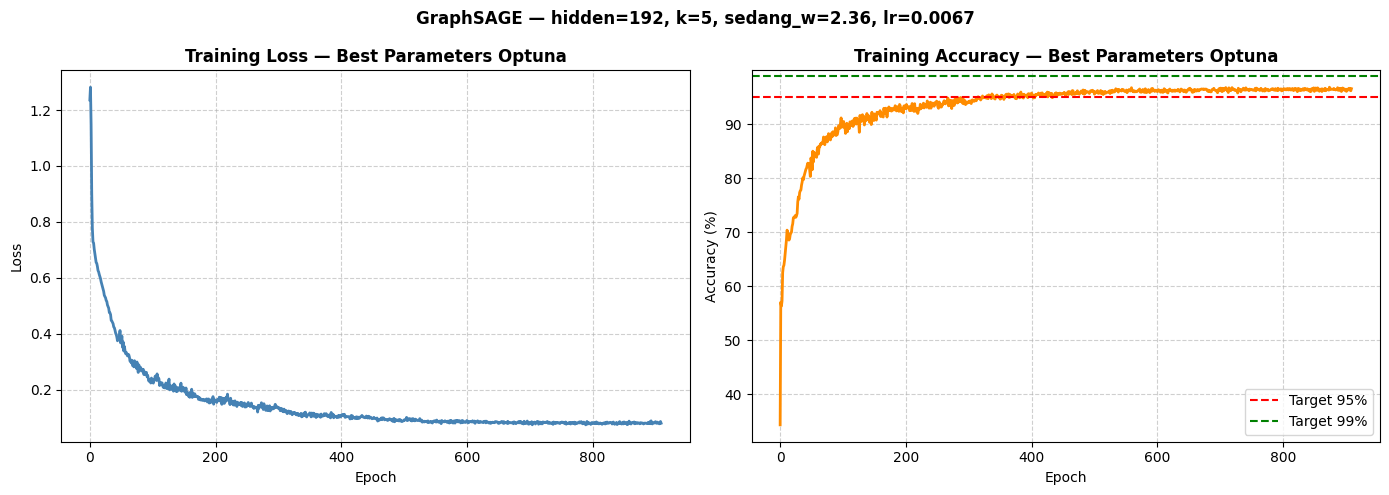

Best Training Loss : 0.0736
Best Training Acc  : 96.30%


In [47]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(losses_best, linewidth=2, color='steelblue')
axes[0].set_title('Training Loss — Best Parameters Optuna', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot([a*100 for a in accs_best], linewidth=2, color='darkorange')
axes[1].axhline(y=95, color='red',   linestyle='--', lw=1.5, label='Target 95%')
axes[1].axhline(y=99, color='green', linestyle='--', lw=1.5, label='Target 99%')
axes[1].set_title('Training Accuracy — Best Parameters Optuna', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.suptitle(
    f'GraphSAGE — hidden=192, k=5, sedang_w=2.36, lr=0.0067',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('grafik_training_best_optuna.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Best Training Loss : {best_loss_b:.4f}')
print(f'Best Training Acc  : {best_acc_b*100:.2f}%')


HASIL EVALUASI — BEST PARAMETERS DARI OPTUNA
Accuracy  : 96.33%
Precision : 0.9649
Recall    : 0.9633
F1-Score  : 0.9635
ROC-AUC   : 0.9976

F1 per Kelas:
  Rendah : 0.9799
  Sedang : 0.9523  ← target utama
  Tinggi : 0.9582

Classification Report:
              precision    recall  f1-score   support

      Rendah       0.99      0.97      0.98       800
      Sedang       0.92      0.99      0.95       800
      Tinggi       0.99      0.93      0.96       801

    accuracy                           0.96      2401
   macro avg       0.96      0.96      0.96      2401
weighted avg       0.96      0.96      0.96      2401



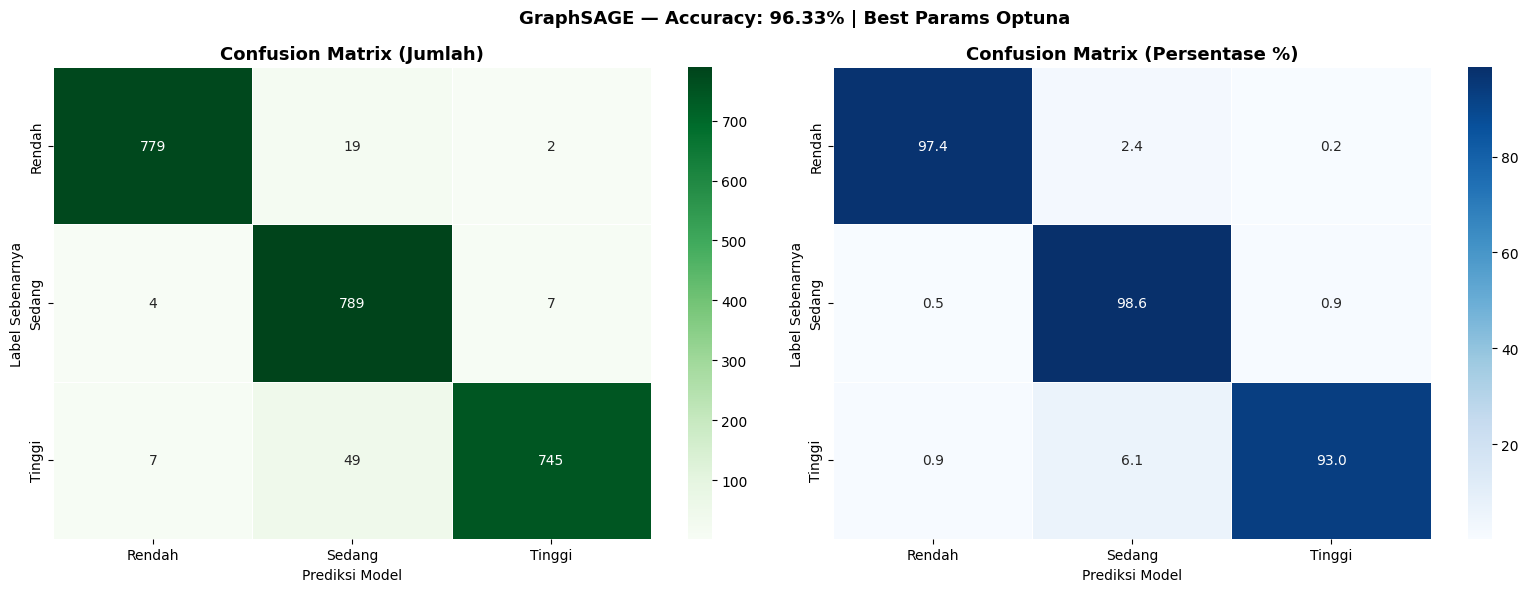


PERBANDINGAN SEBELUM vs SESUDAH OPTIMASI
  Metrik                  Sebelum    Sesudah    Delta
  --------------------------------------------------
  Accuracy                 0.9162     0.9633 + 0.0471
  F1-Score                 0.9162     0.9635 + 0.0473
  F1 Rendah                0.9400     0.9799 + 0.0399
  F1 Sedang                0.8900     0.9523 + 0.0623
  F1 Tinggi                0.9200     0.9582 + 0.0382


In [48]:
import numpy as np, torch, torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix
)
import seaborn as sns, matplotlib.pyplot as plt

y_pred_best, y_prob_best = predict_with_graph(
    model_best, X_te_best.values, X_tr_best.values,
    k=BEST_PARAMS['k_neighbors']
)

acc_b  = accuracy_score(y_te_best, y_pred_best)
prec_b = precision_score(y_te_best, y_pred_best, average='weighted')
rec_b  = recall_score(y_te_best, y_pred_best, average='weighted')
f1_b   = f1_score(y_te_best, y_pred_best, average='weighted')
auc_b  = roc_auc_score(y_te_best, y_prob_best, multi_class='ovr', average='weighted')
f1_per = f1_score(y_te_best, y_pred_best, average=None, zero_division=0)

print('=' * 65)
print('HASIL EVALUASI — BEST PARAMETERS DARI OPTUNA')
print('=' * 65)
print(f'Accuracy  : {acc_b*100:.2f}%')
print(f'Precision : {prec_b:.4f}')
print(f'Recall    : {rec_b:.4f}')
print(f'F1-Score  : {f1_b:.4f}')
print(f'ROC-AUC   : {auc_b:.4f}')
print(f'\nF1 per Kelas:')
print(f'  Rendah : {f1_per[0]:.4f}')
print(f'  Sedang : {f1_per[1]:.4f}  ← target utama')
print(f'  Tinggi : {f1_per[2]:.4f}')

target_names = ['Rendah','Sedang','Tinggi']
print('\nClassification Report:')
print(classification_report(y_te_best, y_pred_best, target_names=target_names))

# Confusion Matrix ganda
cm = confusion_matrix(y_te_best, y_pred_best)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Confusion Matrix (Jumlah)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Prediksi Model')
axes[0].set_ylabel('Label Sebenarnya')

cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names,
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Confusion Matrix (Persentase %)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Prediksi Model')
axes[1].set_ylabel('Label Sebenarnya')

plt.suptitle(
    f'GraphSAGE — Accuracy: {acc_b*100:.2f}% | Best Params Optuna',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('confusion_matrix_best_optuna.png', dpi=300, bbox_inches='tight')
plt.show()

# Perbandingan
print('\n' + '=' * 65)
print('PERBANDINGAN SEBELUM vs SESUDAH OPTIMASI')
print('=' * 65)
print(f'  {"Metrik":20s} {"Sebelum":>10s} {"Sesudah":>10s} {"Delta":>8s}')
print(f'  {"-"*50}')
rows = [
    ("Accuracy",  0.9162, acc_b),
    ("F1-Score",  0.9162, f1_b),
    ("F1 Rendah", 0.9400, f1_per[0]),
    ("F1 Sedang", 0.8900, f1_per[1]),
    ("F1 Tinggi", 0.9200, f1_per[2]),
]
for name, before, after in rows:
    delta = after - before
    sign  = "+" if delta >= 0 else ""
    print(f'  {name:20s} {before:>10.4f} {after:>10.4f} {sign}{delta:>7.4f}')


### Apa Output yang Dihasilkan Model GNN Ini?

`GraphSAGE.forward()` menghasilkan **logits** berukuran `(jumlah_node, 3)` — satu baris per orang (node), 3 kolom untuk skor kelas Rendah/Sedang/Tinggi. Setelah `softmax` (dilakukan di `predict_with_graph`), ini jadi **distribusi probabilitas** (jumlah tiap baris = 1), dan kelas prediksi = `argmax`-nya. Itulah yang dipakai untuk `accuracy_score`, `confusion_matrix`, dst.

Selain itu, `GraphSAGE.get_embeddings()` mengambil keluaran **sebelum layer klasifikasi terakhir** — sebuah vektor laten `hidden_dim // 2` dimensi per node. Vektor ini bukan probabilitas, tapi "posisi" tiap orang dalam ruang representasi yang sudah menyerap informasi dari tetangga-tetangganya (hasil 3 layer agregasi SAGEConv). Karena dimensinya tinggi, embedding ini diproyeksikan ke 2D (PCA/t-SNE) di sel berikut agar bisa dilihat langsung — idealnya titik-titik dengan warna kelas yang sama akan mengelompok, menunjukkan model berhasil memisahkan pola gaya hidup tiap kategori risiko.


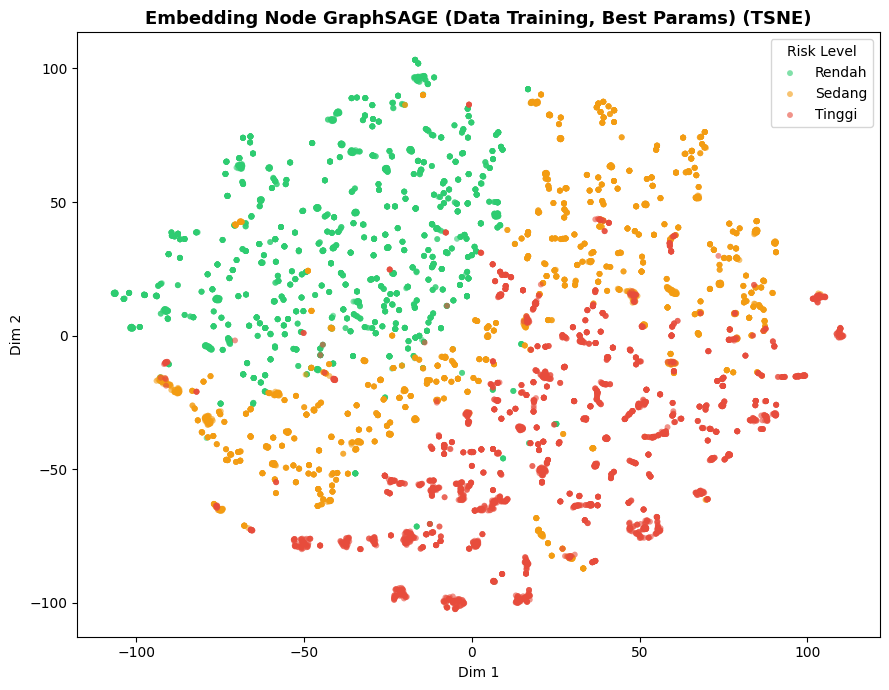

In [49]:
# ============================================================
# VISUALISASI NODE — Embedding Laten Model GraphSAGE (get_embeddings)
# Proyeksi ke 2D (t-SNE / PCA) untuk melihat bagaimana model
# mengelompokkan node menurut tingkat risikonya.
# ============================================================
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def visualize_node_embeddings(model, X_arr, y_arr, k=5, method='tsne',
                               title='Visualisasi Embedding Node GraphSAGE'):
    model.eval()
    edge_idx, _ = build_knn_graph(X_arr, k=k)
    x_tensor = torch.tensor(X_arr, dtype=torch.float32)

    with torch.no_grad():
        emb = model.get_embeddings(x_tensor, edge_idx).cpu().numpy()

    reducer = PCA(n_components=2, random_state=42) if method == 'pca' else \
              TSNE(n_components=2, random_state=42, perplexity=30, init='pca')
    emb_2d = reducer.fit_transform(emb)

    target_names = ['Rendah', 'Sedang', 'Tinggi']
    colors = ['#2ecc71', '#f39c12', '#e74c3c']

    plt.figure(figsize=(9, 7))
    for i, cls in enumerate(target_names):
        mask = y_arr == i
        plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                    c=colors[i], label=cls, alpha=0.6, s=18, edgecolors='none')
    plt.legend(title='Risk Level')
    plt.title(f'{title} ({method.upper()})', fontsize=13, fontweight='bold')
    plt.xlabel('Dim 1'); plt.ylabel('Dim 2')
    plt.tight_layout()
    plt.savefig(f'node_embedding_{method}.png', dpi=300, bbox_inches='tight')
    plt.show()
    return emb, emb_2d

# Embedding pada data training (graf sama seperti yang dipakai saat training)
emb_train, emb_train_2d = visualize_node_embeddings(
    model_best, X_tr_best.values, y_tr_best.values,
    k=BEST_PARAMS['k_neighbors'], method='tsne',
    title='Embedding Node GraphSAGE (Data Training, Best Params)'
)


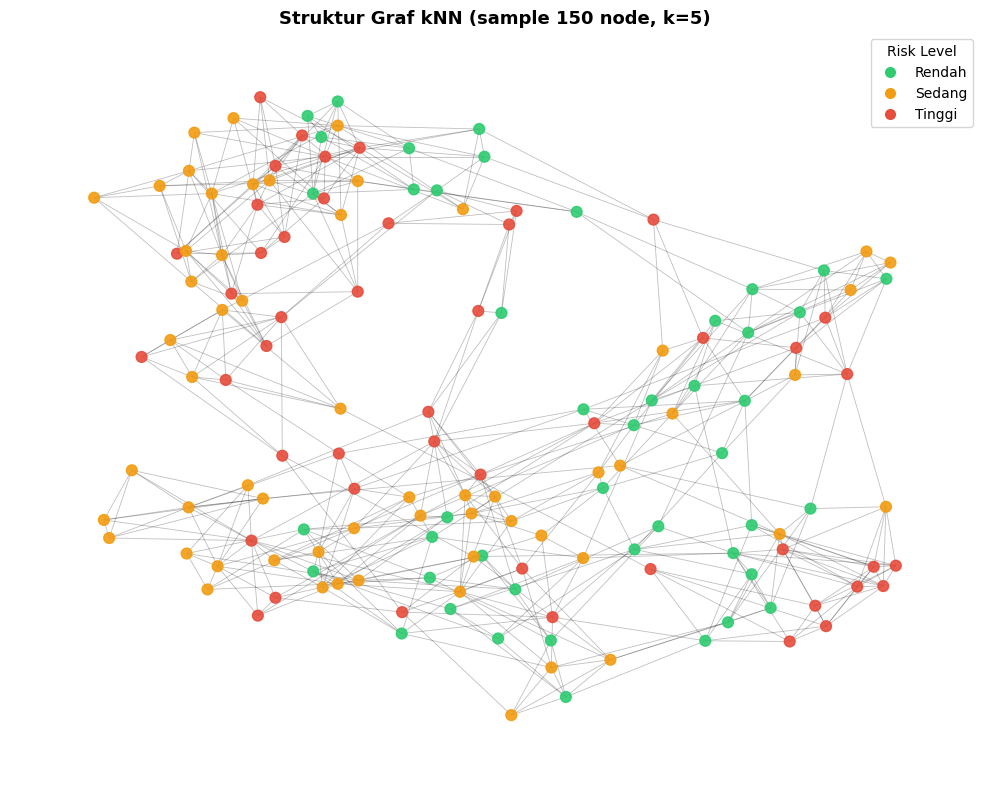

Node: 150 | Edge: 510 | Rata-rata derajat: 6.80


In [50]:
# ============================================================
# VISUALISASI NODE — Struktur Graf kNN (sample node & edge)
# Menunjukkan bentuk graf yang benar-benar dipakai GraphSAGE:
# node = individu, edge = kemiripan cosine antar fitur gaya hidup.
# ============================================================
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

def visualize_knn_graph_sample(X_arr, y_arr, k=5, n_sample=150, seed=42,
                                title='Struktur Graf kNN'):
    rng = np.random.default_rng(seed)
    n_sample = min(n_sample, len(X_arr))
    idx_sample = rng.choice(len(X_arr), size=n_sample, replace=False)
    X_sample = X_arr[idx_sample]
    y_sample = np.asarray(y_arr)[idx_sample]

    edge_idx, _ = build_knn_graph(X_sample, k=k)
    edges = edge_idx.t().numpy()

    G = nx.Graph()
    for i in range(len(X_sample)):
        G.add_node(i, label=int(y_sample[i]))
    G.add_edges_from(edges.tolist())

    target_names = ['Rendah', 'Sedang', 'Tinggi']
    colors_map = ['#2ecc71', '#f39c12', '#e74c3c']
    node_colors = [colors_map[G.nodes[n]['label']] for n in G.nodes()]

    pos = nx.spring_layout(G, seed=seed, k=0.3)
    plt.figure(figsize=(10, 8))
    nx.draw_networkx_edges(G, pos, alpha=0.25, width=0.6)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=60, alpha=0.9)
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                           markersize=9, label=t)
               for c, t in zip(colors_map, target_names)]
    plt.legend(handles=handles, title='Risk Level')
    plt.title(f'{title} (sample {len(X_sample)} node, k={k})', fontsize=13, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('graph_structure_sample.png', dpi=300, bbox_inches='tight')
    plt.show()

    avg_deg = 2 * G.number_of_edges() / G.number_of_nodes()
    print(f'Node: {G.number_of_nodes()} | Edge: {G.number_of_edges()} | Rata-rata derajat: {avg_deg:.2f}')
    return G

G_sample = visualize_knn_graph_sample(
    X_tr_best.values, y_tr_best.values, k=BEST_PARAMS['k_neighbors']
)


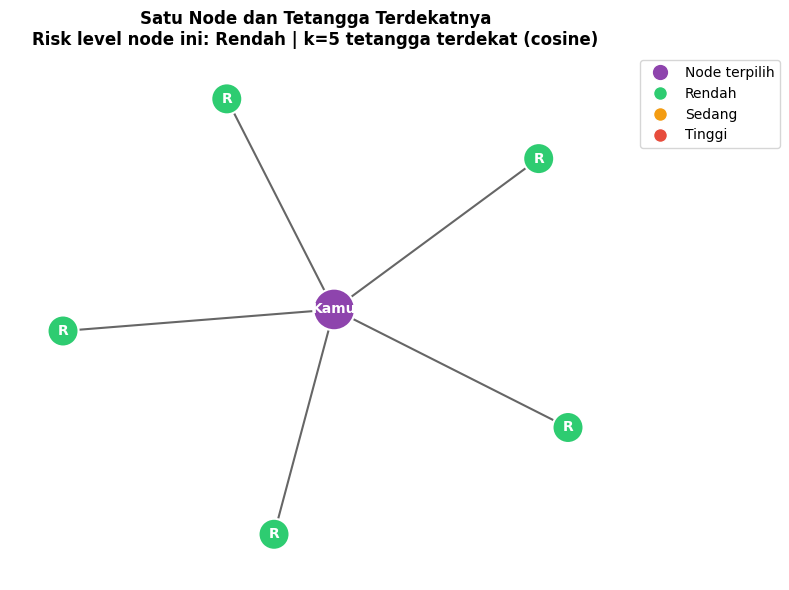

Node terpilih (index 0) - Risk level: Rendah
Tetangga terdekatnya (index): [9288, 5715, 3254, 5330, 3436]
Risk level tiap tetangga:
  Node 9288: Rendah
  Node 5715: Rendah
  Node 3254: Rendah
  Node 5330: Rendah
  Node 3436: Rendah


In [52]:
# ============================================================
# VISUALISASI NODE & EDGE — Contoh 1 Orang dan Tetangga Terdekatnya
# (versi sederhana: fokus ke SATU node, biar gampang dijelaskan ke dosen)
# ============================================================
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

def visualize_single_node_and_neighbors(X_arr, y_arr, node_idx=0, k=5, seed=42,
                                         title='Satu Node dan Tetangga Terdekatnya'):
    X_arr = np.asarray(X_arr)
    y_arr = np.asarray(y_arr)

    # Cari k tetangga terdekat untuk node_idx, pakai metric sama seperti build_knn_graph (cosine)
    knn = NearestNeighbors(n_neighbors=k + 1, metric='cosine')
    knn.fit(X_arr)
    _, indices = knn.kneighbors(X_arr[node_idx:node_idx + 1])
    neighbor_idx = indices[0][1:]  # index 0 dibuang karena itu dirinya sendiri

    G = nx.Graph()
    G.add_node(node_idx, label=int(y_arr[node_idx]))
    for n in neighbor_idx:
        G.add_node(n, label=int(y_arr[n]))
        G.add_edge(node_idx, n)

    target_names = ['Rendah', 'Sedang', 'Tinggi']
    colors_map   = ['#2ecc71', '#f39c12', '#e74c3c']

    pos = nx.spring_layout(G, seed=seed, k=0.8)
    node_colors = [colors_map[G.nodes[n]['label']] if n != node_idx else '#8e44ad' for n in G.nodes()]
    node_sizes  = [900 if n == node_idx else 500 for n in G.nodes()]

    plt.figure(figsize=(8, 6))
    nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.6)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes,
                            edgecolors='white', linewidths=1.5)
    labels = {node_idx: 'Kamu'}
    labels.update({n: target_names[G.nodes[n]['label']][0] for n in neighbor_idx})
    nx.draw_networkx_labels(G, pos, labels=labels, font_color='white', font_weight='bold', font_size=10)

    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#8e44ad',
                           markersize=12, label='Node terpilih')]
    handles += [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, label=t)
                for c, t in zip(colors_map, target_names)]
    plt.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.02, 1))
    plt.title(f'{title}\nRisk level node ini: {target_names[int(y_arr[node_idx])]} | '
              f'k={k} tetangga terdekat (cosine)', fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('single_node_neighbors.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f'Node terpilih (index {node_idx}) - Risk level: {target_names[int(y_arr[node_idx])]}')
    print(f'Tetangga terdekatnya (index): {neighbor_idx.tolist()}')
    print('Risk level tiap tetangga:')
    for n in neighbor_idx:
        print(f'  Node {n}: {target_names[int(y_arr[n])]}')

# Ganti node_idx dengan index orang mana pun yang mau kamu tunjukkan
visualize_single_node_and_neighbors(
    X_tr_best.values, y_tr_best.values, node_idx=0, k=BEST_PARAMS['k_neighbors']
)

### Kenapa Akurasi Meningkat Setelah Tuning Optuna?

Membandingkan model awal (cell training pertama: `hidden_dim=128, dropout=0.3, lr=0.001`, augmentasi 2000/kelas, tanpa class weight) dengan `model_best` (parameter Optuna Trial #42), ada 5 perubahan yang saling melengkapi:

| Perubahan | Sebelum → Sesudah | Efeknya |
|---|---|---|
| **Kapasitas model** | `hidden_dim` 128 → 192 | Lebih banyak parameter untuk menangkap pola non-linear antar fitur gaya hidup yang kompleks. |
| **Regularisasi** | `dropout` 0.3 → 0.159 | Data latih sudah jauh lebih banyak (augmentasi 2500/kelas + ekstra), jadi risiko overfitting lebih kecil — dropout tinggi tidak lagi diperlukan dan malah menghambat model belajar pola halus. |
| **Kecepatan belajar** | `lr` 0.001 → 0.0067 (≈6.7x) | Konvergensi ke loss minimum lebih cepat dalam anggaran epoch/`patience` yang sama, dibantu `ReduceLROnPlateau` agar tetap stabil menjelang akhir training. |
| **Data untuk kelas ambigu** | augmentasi Sedang +1000 ekstra | Kelas **Sedang** (Overweight I & II) paling gampang tertukar ke Rendah *atau* Tinggi karena polanya di "zona abu-abu". Menambah variasi data sintetis khusus kelas ini membantu model mengenali batas kelasnya lebih baik. |
| **Loss berbobot** | `CrossEntropyLoss` polos → `sedang_weight = 2.363x` | Model "dipaksa" lebih fokus mengoreksi kesalahan pada kelas Sedang, karena kesalahan di kelas ini di-*penalti* 2.36x lebih besar dibanding Rendah/Tinggi saat backpropagation. |

Perubahan yang sama sekali **tidak diubah** — `k_neighbors` tetap 5 — menunjukkan bahwa perbaikan utamanya datang dari **kapasitas model + kualitas/porsi data**, bukan dari mengubah struktur graf kNN itu sendiri. Angka pasti *before/after* (accuracy, F1 per kelas) tercetak otomatis di tabel perbandingan pada sel evaluasi di atas setiap kali notebook ini dijalankan ulang — nilai "Sebelum" sudah dikunci ke hasil run pertama (0.9162), sedangkan "Sesudah" dihitung live dari `model_best`.

Secara singkat: **akurasi naik bukan karena satu trik tunggal**, tapi karena Optuna menemukan kombinasi kapasitas-regularisasi-learning rate yang pas untuk ukuran data baru, DAN strategi tambahan (augmentasi + class weight) yang menyasar langsung titik terlemah model sebelumnya (kelas Sedang).


In [51]:
import torch, joblib

torch.save(model_best.state_dict(), 'model_gnn_best.pth')
joblib.dump(scaler_best, 'scaler_best.pkl')
joblib.dump(le_best,     'label_encoder_best.pkl')
joblib.dump(BEST_PARAMS, 'best_params.pkl')

print('Semua file tersimpan!')
print('  model_gnn_best.pth')
print('  scaler_best.pkl')
print('  label_encoder_best.pkl')
print('  best_params.pkl')


Semua file tersimpan!
  model_gnn_best.pth
  scaler_best.pkl
  label_encoder_best.pkl
  best_params.pkl
